# Car Price Prediction Challenge

**Problema obtenido de Kaggle:** [Car Price Prediction Challenge](https://www.kaggle.com/datasets/deepcontractor/car-price-prediction-challenge/data)

## Introduccion

El objetivo de este proyecto es predecir el **precio de venta de vehiculos de segunda mano** a partir de sus caracteristicas tecnicas y comerciales. Se trata de un problema de **regresion supervisada**.

El dataset contiene **19.237 vehiculos** con 18 variables, entre ellas: fabricante, modelo, ano de produccion, tipo de combustible, volumen del motor, kilometraje, cilindros, tipo de cambio, traccion, numero de puertas, color y airbags.

A lo largo del analisis se realiza una limpieza y exploracion de los datos (EDA), seguida del entrenamiento y comparacion de tres modelos de Machine Learning: **Regresion Lineal**, **Random Forest** y **XGBoost**.


In [2]:
import pandas as pd

df = pd.read_csv('car_price_prediction.csv')
print(df.shape)
df.head()

(19237, 18)


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [3]:
df['Doors'].value_counts()

Doors
04-May    18332
02-Mar      777
>5          128
Name: count, dtype: int64

In [4]:
df['Doors'] = df['Doors'].str[:2]
df['Doors'].value_counts()


Doors
04    18332
02      777
>5      128
Name: count, dtype: int64

In [5]:
df['Mileage'].value_counts()

Mileage
0 km         721
200000 km    183
150000 km    161
160000 km    120
100000 km    119
            ... 
23430 km       1
132700 km      1
140607 km      1
307325 km      1
186923 km      1
Name: count, Length: 7687, dtype: int64

In [6]:
df['Mileage'].str.contains('km').value_counts()

Mileage
True    19237
Name: count, dtype: int64

In [7]:
df.shape

(19237, 18)

In [8]:
df['Mileage'] = df['Mileage'].str.replace('km', '').astype(float)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  float64
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237 non-null  str    
 17  Airb

In [10]:
df['Levy'] = pd.to_numeric(df['Levy'], errors='coerce')
df['Engine volume'] = pd.to_numeric(df['Engine volume'], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              13418 non-null  float64
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     17306 non-null  float64
 10  Mileage           19237 non-null  float64
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237 non-null  str    
 17  Airb

In [11]:
df.describe()

,ID,Price,Levy,Prod. year,Engine volume,Mileage,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,13418.000000,19237.000000,17306.000000,1.923700e+04,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,906.838128,2010.912824,2.312990,1.532236e+06,4.582991,6.582627
std,9.365914e+05,1.905813e+05,461.867051,5.668673,0.888156,4.840387e+07,1.199933,4.320168
min,2.074688e+07,1.000000e+00,87.000000,1939.000000,0.000000,0.000000e+00,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,640.000000,2009.000000,1.800000,7.013900e+04,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,781.000000,2012.000000,2.000000,1.260000e+05,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,1058.000000,2015.000000,2.500000,1.888880e+05,4.000000,12.000000
max,4.581665e+07,2.630750e+07,11714.000000,2020.000000,20.000000,2.147484e+09,16.000000,16.000000


In [12]:
df.drop(columns= ['ID'], inplace=True)
df.describe()

,Price,Levy,Prod. year,Engine volume,Mileage,Cylinders,Airbags
count,1.923700e+04,13418.000000,19237.000000,17306.000000,1.923700e+04,19237.000000,19237.000000
mean,1.855593e+04,906.838128,2010.912824,2.312990,1.532236e+06,4.582991,6.582627
std,1.905813e+05,461.867051,5.668673,0.888156,4.840387e+07,1.199933,4.320168
min,1.000000e+00,87.000000,1939.000000,0.000000,0.000000e+00,1.000000,0.000000
25%,5.331000e+03,640.000000,2009.000000,1.800000,7.013900e+04,4.000000,4.000000
50%,1.317200e+04,781.000000,2012.000000,2.000000,1.260000e+05,4.000000,6.000000
75%,2.207500e+04,1058.000000,2015.000000,2.500000,1.888880e+05,4.000000,12.000000
max,2.630750e+07,11714.000000,2020.000000,20.000000,2.147484e+09,16.000000,16.000000


In [13]:
df.isnull().sum()

Price                  0
Levy                5819
Manufacturer           0
Model                  0
Prod. year             0
Category               0
Leather interior       0
Fuel type              0
Engine volume       1931
Mileage                0
Cylinders              0
Gear box type          0
Drive wheels           0
Doors                  0
Wheel                  0
Color                  0
Airbags                0
dtype: int64

In [14]:
df['Levy'] = df['Levy'].fillna(0)

In [15]:
df.isnull().sum()

Price                  0
Levy                   0
Manufacturer           0
Model                  0
Prod. year             0
Category               0
Leather interior       0
Fuel type              0
Engine volume       1931
Mileage                0
Cylinders              0
Gear box type          0
Drive wheels           0
Doors                  0
Wheel                  0
Color                  0
Airbags                0
dtype: int64

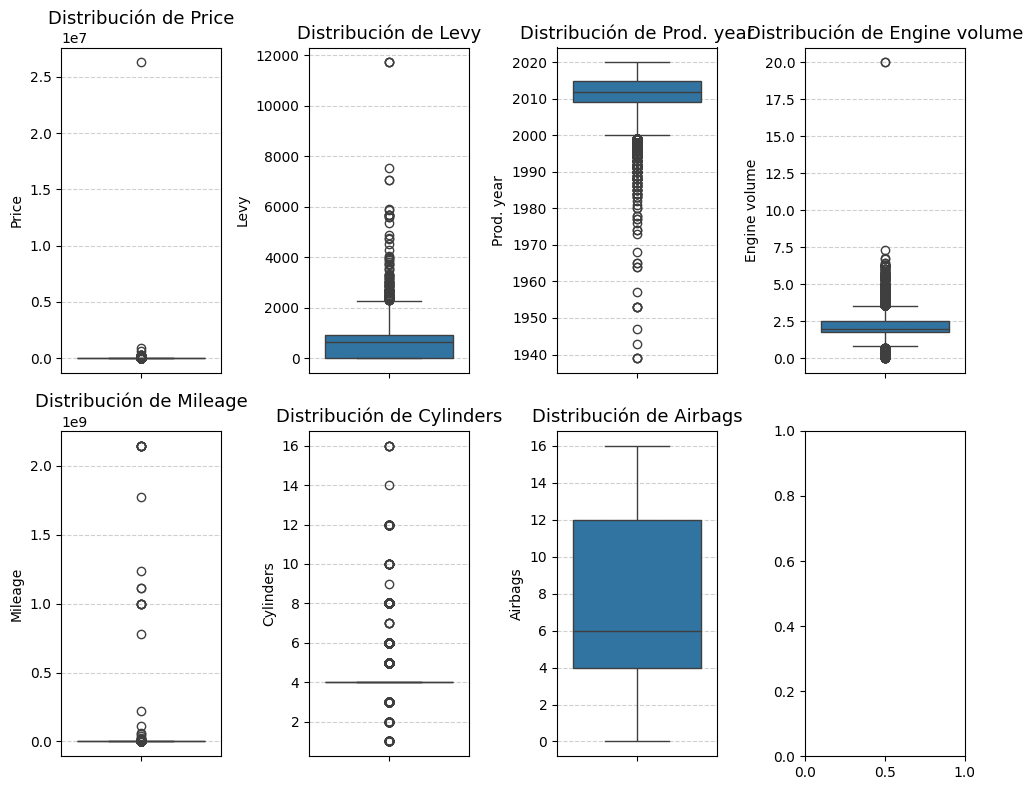

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include="number").columns.tolist()

# Configuración de la figura (creamos una cuadrícula de subplots)
fig, axes = plt.subplots(ncols=4, nrows=2, figsize=(10, 8))
axes = axes.flatten()

# Iteración para pintar cada boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i],
        orient='y',
        legend=False
    )
    axes[i].set_title(f'Distribución de {col}', fontsize=13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [17]:
import numpy as np

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numericas: ", num_cols)
cat_cols = df.select_dtypes(include=[object]).columns.tolist()
print("Categoricas: ", cat_cols)

Numericas:  ['Price', 'Levy', 'Prod. year', 'Engine volume', 'Mileage', 'Cylinders', 'Airbags']
Categoricas:  ['Manufacturer', 'Model', 'Category', 'Leather interior', 'Fuel type', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color']


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4868\421098468.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=[object]).columns.tolist()


> La variable numérica de Price, posee un outlier claro

In [18]:
df[df['Price'] > 500000]

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
1225,627220,0.0,MERCEDES-BENZ,G 65 AMG 63AMG,2020,Jeep,Yes,Petrol,NaN,0.0,8.0,Tiptronic,4x4,04,Left wheel,Black,12
8541,872946,2067.0,LAMBORGHINI,Urus,2019,Universal,Yes,Petrol,4.0,2531.0,8.0,Tiptronic,4x4,04,Left wheel,Black,0
16983,26307500,0.0,OPEL,Combo,1999,Goods wagon,No,Diesel,1.7,99999.0,4.0,Manual,Front,02,Left wheel,Blue,0


In [19]:
df[(df['Price'] > 500000) & (df['Manufacturer'] == 'OPEL')]

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
16983,26307500,0.0,OPEL,Combo,1999,Goods wagon,No,Diesel,1.7,99999.0,4.0,Manual,Front,02,Left wheel,Blue,0


In [20]:
df.drop(df[(df['Price'] > 500000) & (df['Manufacturer'] == 'OPEL')].index, inplace=True)

In [21]:
df.drop(df[df['Price'] > 100000].index, inplace=True)

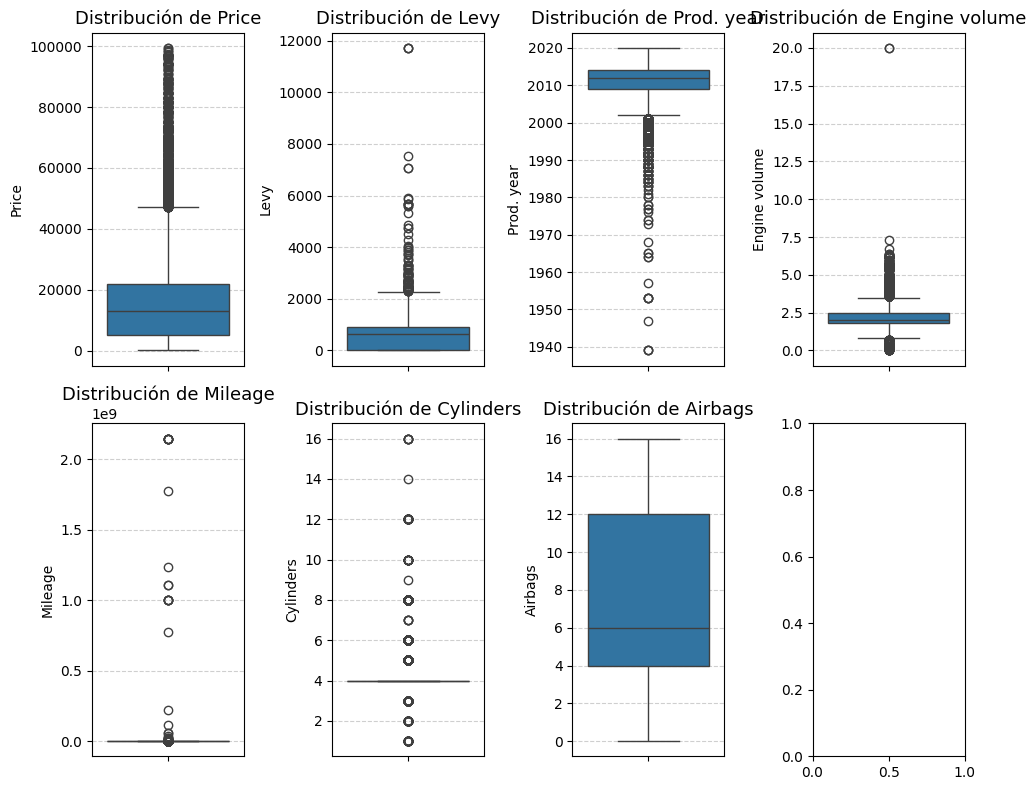

In [22]:

# Configuración de la figura (creamos una cuadrícula de subplots)
fig, axes = plt.subplots(ncols=4, nrows=2, figsize=(10, 8))
axes = axes.flatten()

# Iteración para pintar cada boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i],
        orient='y',
        legend=False  # Quita la leyenda repetitiva
    )
    axes[i].set_title(f'Distribución de {col}', fontsize=13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

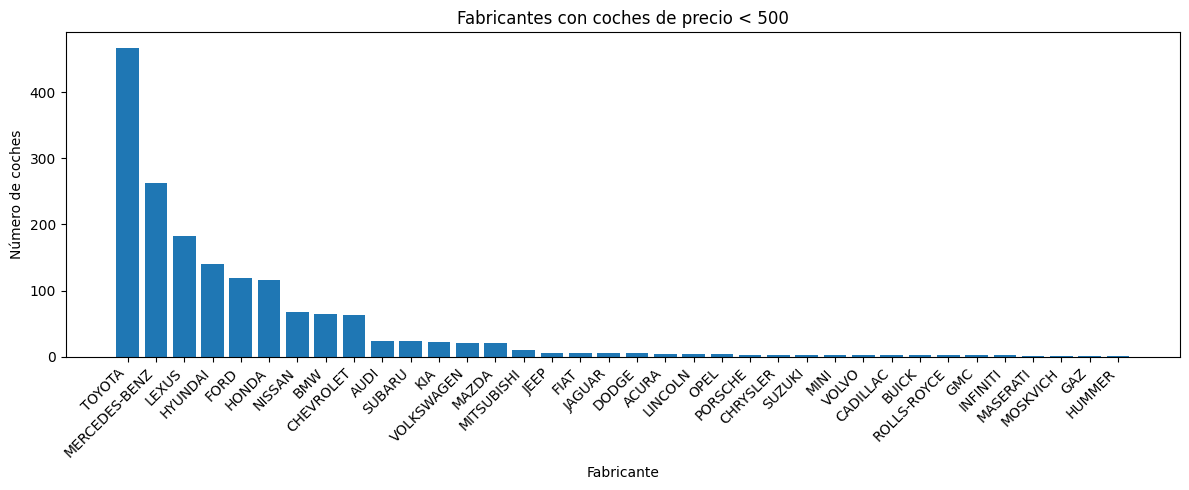

In [23]:
cheap = df[df['Price'] < 500]
manufacturer_counts = cheap['Manufacturer'].value_counts()

plt.figure(figsize=(12, 5))
plt.bar(manufacturer_counts.index, manufacturer_counts.values)
plt.title('Fabricantes con coches de precio < 500')
plt.xlabel('Fabricante')
plt.ylabel('Número de coches')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [24]:
df.drop(df[df['Price'] < 500].index, inplace=True)

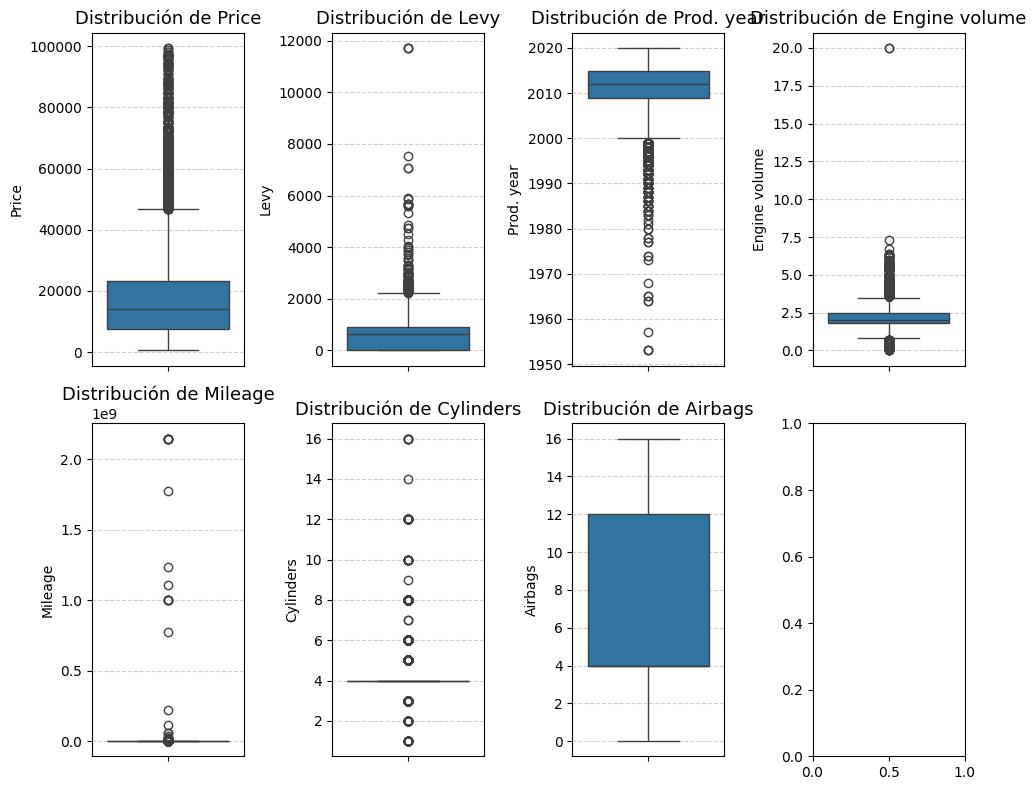

In [25]:

# Configuración de la figura (creamos una cuadrícula de subplots)
fig, axes = plt.subplots(ncols=4, nrows=2, figsize=(10, 8))
axes = axes.flatten()

# Iteración para pintar cada boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i],
        orient='y',
        legend=False  # Quita la leyenda repetitiva
    )
    axes[i].set_title(f'Distribución de {col}', fontsize=13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [26]:
df['Engine volume'].value_counts()

Engine volume
2.0    3702
2.5    2049
1.8    1570
1.6    1413
1.5    1203
       ... 
7.3       1
3.1       1
3.9       1
5.2       1
5.8       1
Name: count, Length: 64, dtype: int64

In [27]:
df[df['Engine volume'] > 10]

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
2357,10036,5603.0,HYUNDAI,Sonata,2014,Sedan,Yes,LPG,20.0,333686.0,4.0,Automatic,Front,04,Left wheel,Silver,4
17777,10036,5603.0,HYUNDAI,Sonata,2014,Sedan,Yes,LPG,20.0,333686.0,4.0,Automatic,Front,04,Left wheel,Silver,4


In [28]:
df.drop(df[df['Engine volume'] > 10].index, inplace=True)

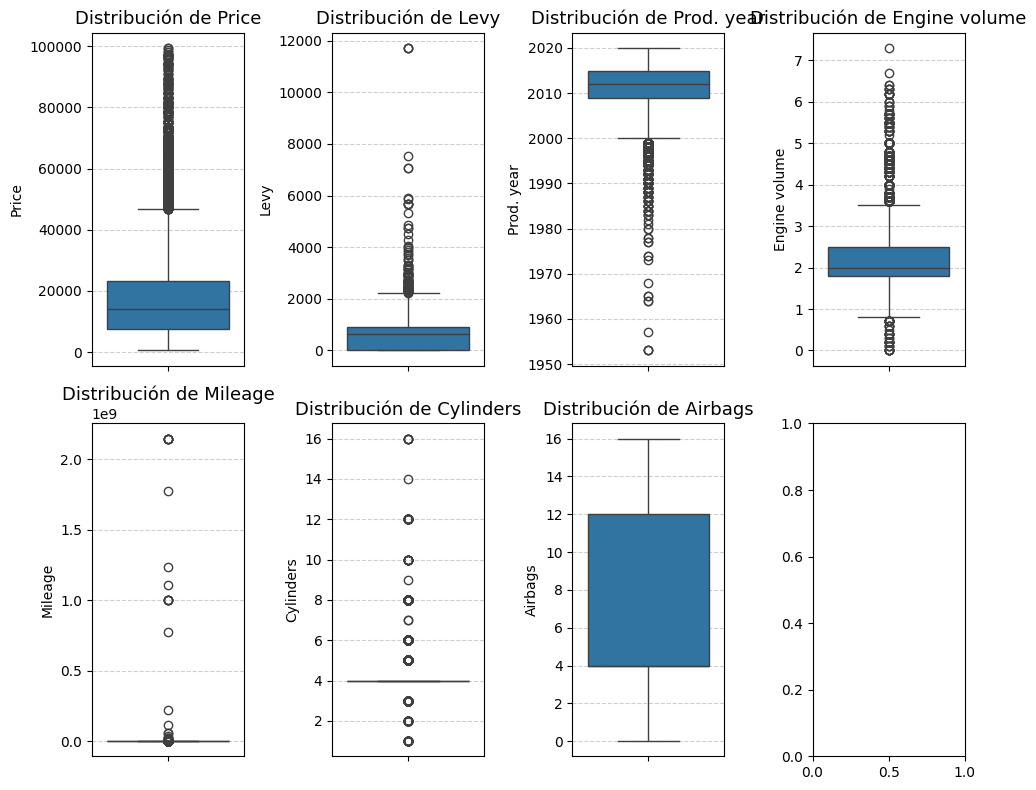

In [29]:
fig, axes = plt.subplots(ncols=4, nrows=2, figsize=(10, 8))
axes = axes.flatten()

# Iteración para pintar cada boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i],
        orient='y',
        legend=False  # Quita la leyenda repetitiva
    )
    axes[i].set_title(f'Distribución de {col}', fontsize=13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [30]:
df['Mileage'].value_counts()

Mileage
0.0         595
200000.0    167
150000.0    132
160000.0    116
180000.0    109
           ... 
65691.0       1
158130.0      1
23430.0       1
132700.0      1
140607.0      1
Name: count, Length: 7214, dtype: int64

In [31]:
df.nlargest(10, 'Mileage')[['Manufacturer', 'Model', 'Mileage']]

,Manufacturer,Model,Mileage
2278,VOLKSWAGEN,Golf,2.147484e+09
6157,MERCEDES-BENZ,C 180,2.147484e+09
11901,SUBARU,Forester,2.147484e+09
12734,UAZ,31514,2.147484e+09
15393,TOYOTA,Prius,2.147484e+09
19167,FORD,Transit,2.147484e+09
17582,MERCEDES-BENZ,E 200,1.777778e+09
7724,OPEL,Corsa,1.234568e+09
19199,MERCEDES-BENZ,C 180,1.111111e+09
5456,NISSAN,X-Terra,1.000000e+09


In [32]:
q3 = df['Mileage'].quantile(0.75)
df.loc[df['Mileage'] > 500000, 'Mileage'] = q3

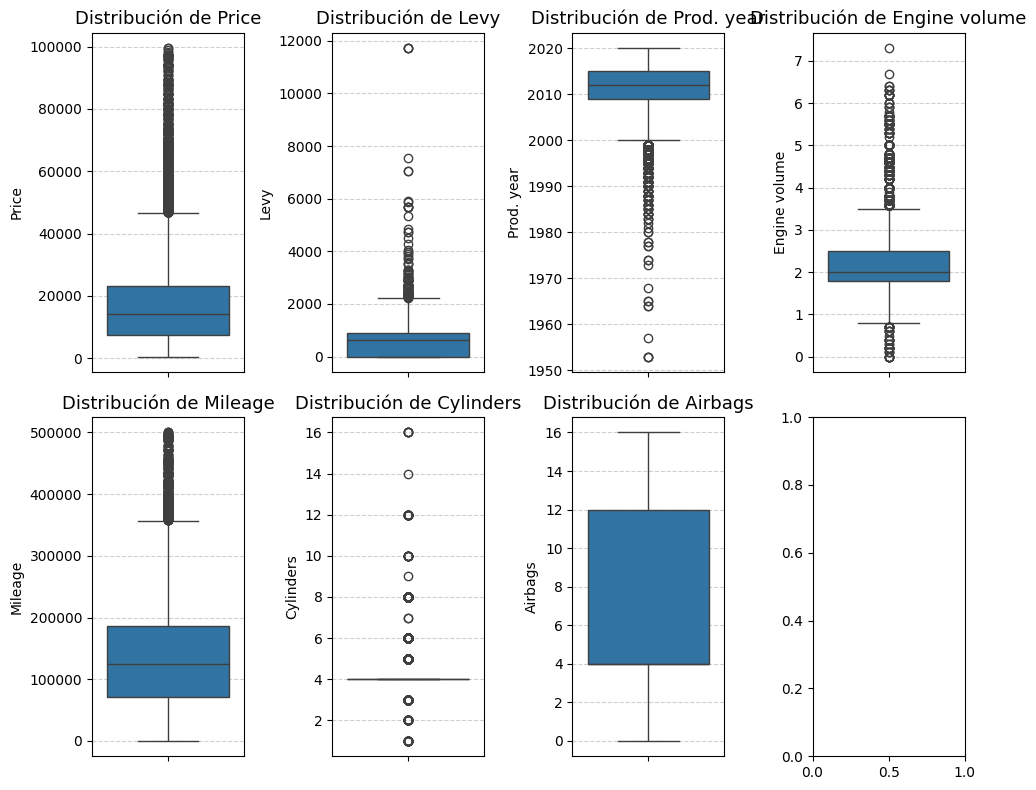

In [33]:
fig, axes = plt.subplots(ncols=4, nrows=2, figsize=(10, 8))
axes = axes.flatten()

# Iteración para pintar cada boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i],
        orient='y',
        legend=False  # Quita la leyenda repetitiva
    )
    axes[i].set_title(f'Distribución de {col}', fontsize=13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

> Por último, en la variable Engine Volume, como los valores estan concentrados próximos a la mediana, es razoanble imputar los datos NaN con la mediana

In [34]:
df['Engine volume'] = df['Engine volume'].fillna(df['Engine volume'].median())

In [35]:
df.isnull().sum()

Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [36]:
df[cat_cols].info()

<class 'pandas.DataFrame'>
Index: 17459 entries, 0 to 19235
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Manufacturer      17459 non-null  str  
 1   Model             17459 non-null  str  
 2   Category          17459 non-null  str  
 3   Leather interior  17459 non-null  str  
 4   Fuel type         17459 non-null  str  
 5   Gear box type     17459 non-null  str  
 6   Drive wheels      17459 non-null  str  
 7   Doors             17459 non-null  str  
 8   Wheel             17459 non-null  str  
 9   Color             17459 non-null  str  
dtypes: str(10)
memory usage: 1.5 MB


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4868\367579889.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4868\367579889.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4868\367579889.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4868\367579889.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to 

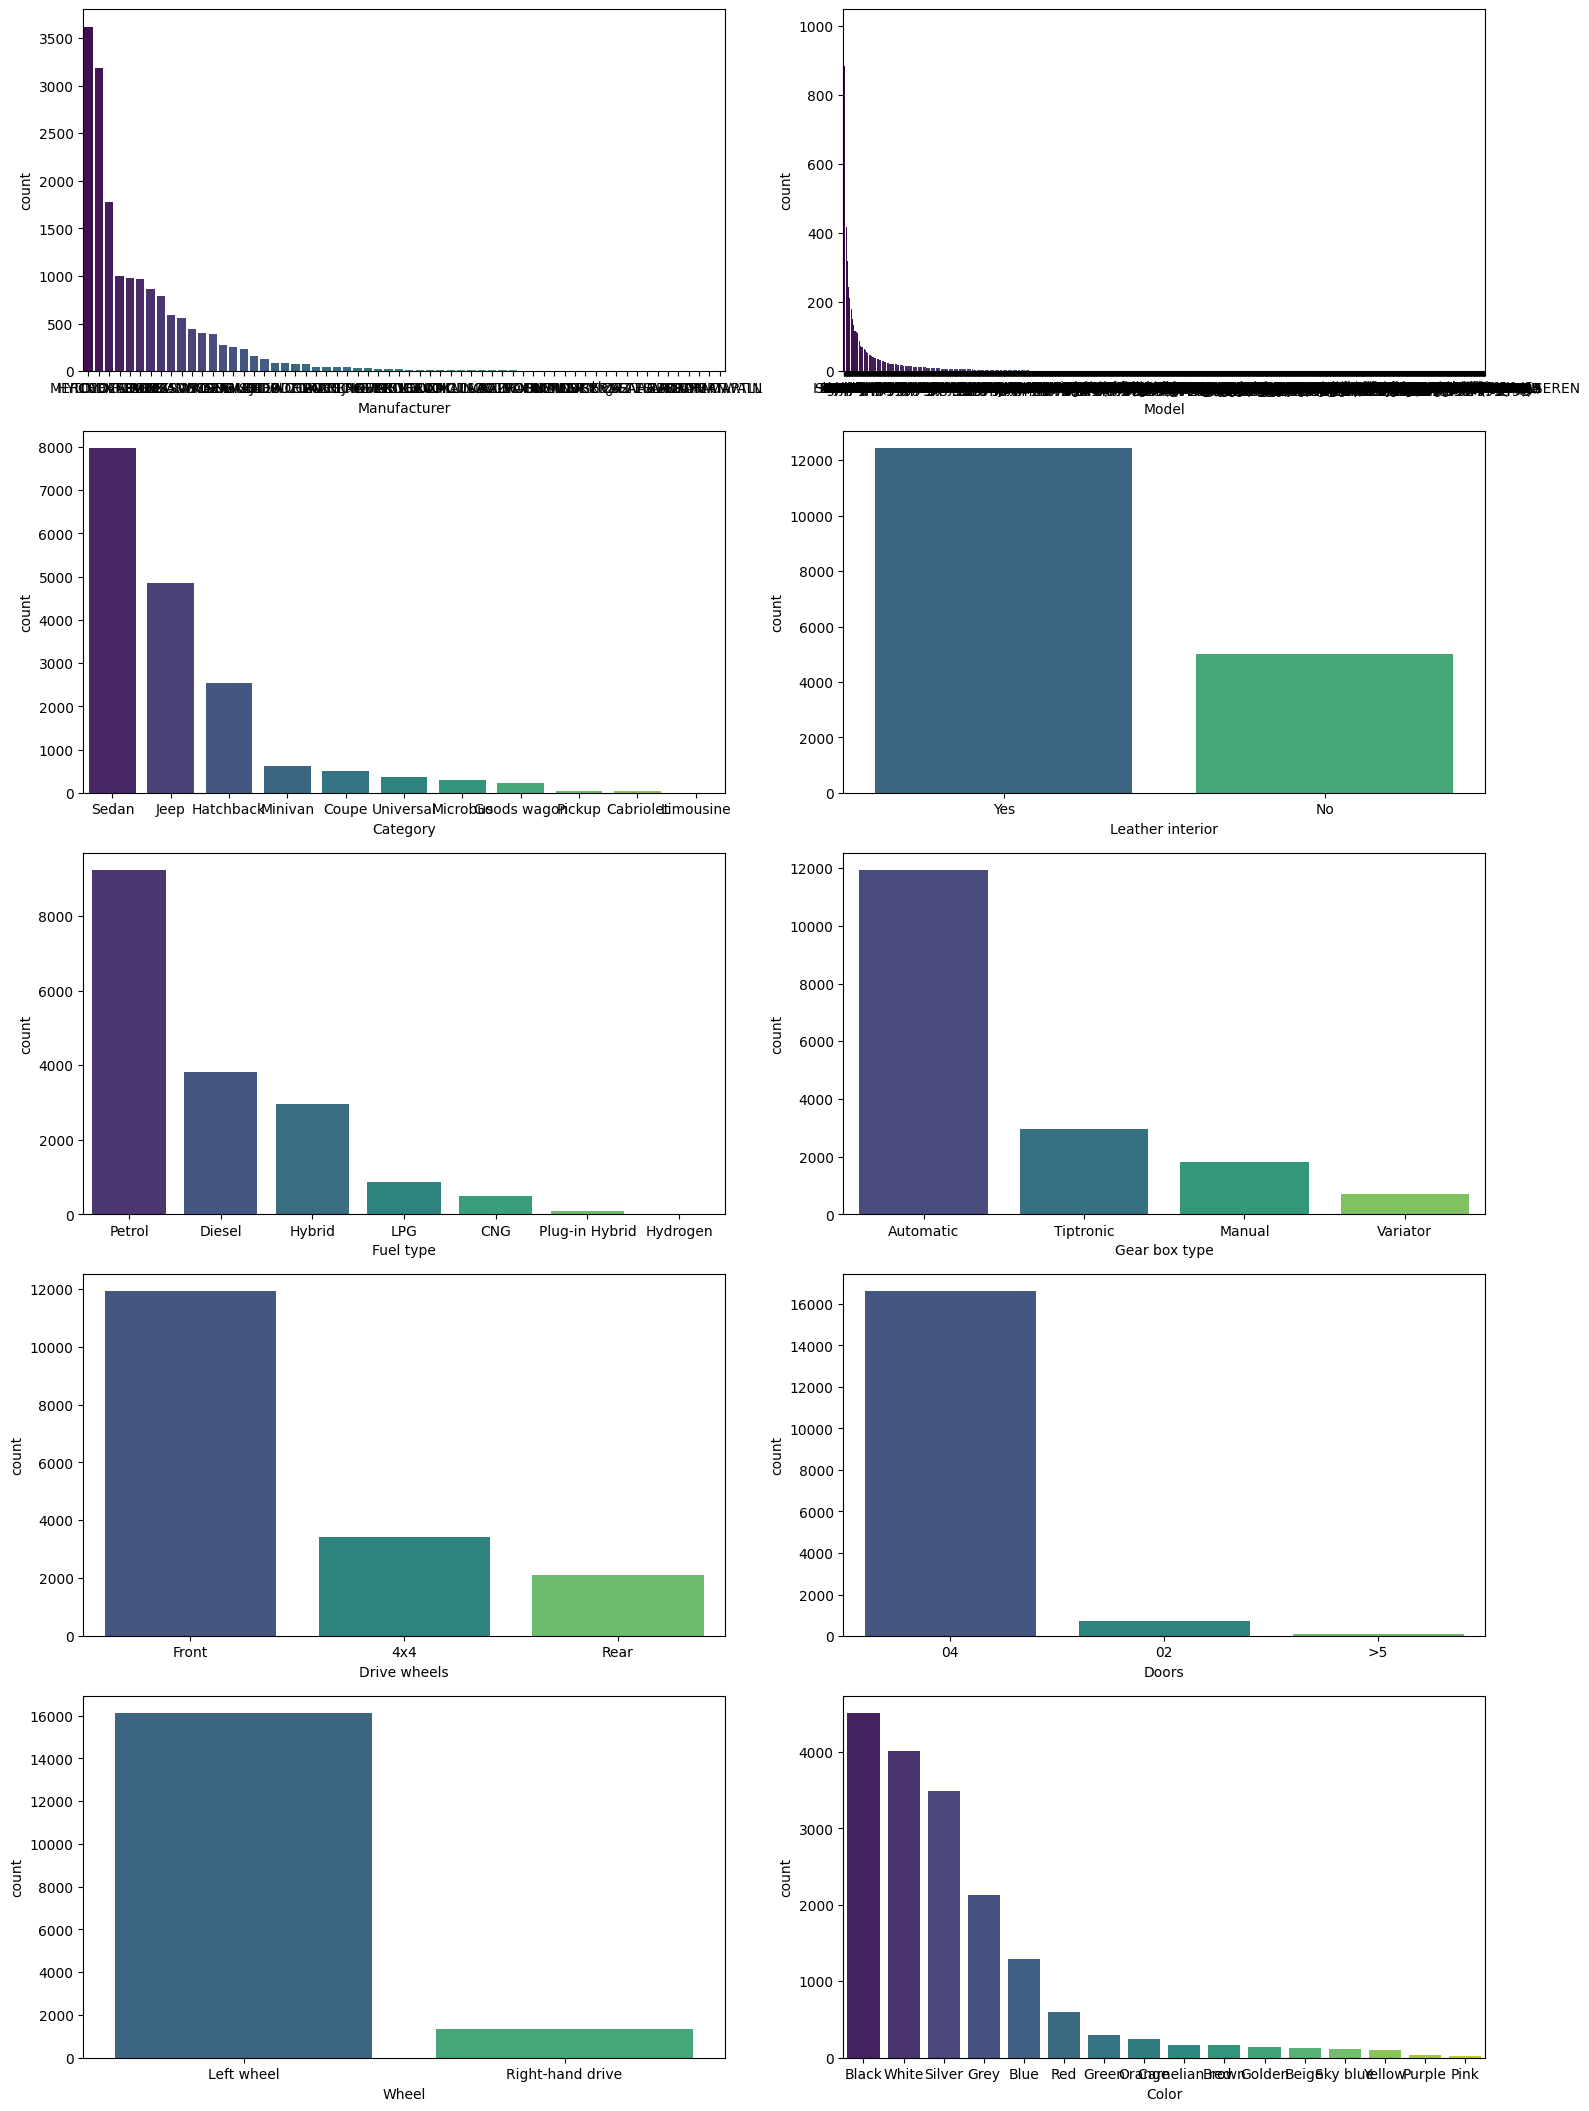

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de la cuadrícula 5x2
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(16, 25))
axes = axes.flatten()

for i, var in enumerate(cat_cols):
    if i < len(axes):
        # Ordenamos las barras por frecuencia descendente
        order = df[var].value_counts().index

        sns.countplot(
            data=df,
            x=var,
            ax=axes[i],
            palette='viridis',
            order=order
        )

# Eliminar subplots vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [38]:
df['Model'].nunique()

1533

> La variable Model introduce mucho ruido, por eso se eliminará

In [39]:
df.shape

(17459, 17)

In [40]:
df.drop('Model', axis=1, inplace=True)

> Eliminada, la variable Manufacturer posee mucho ruido, es por ello por lo que se debe eliminar partes de ellas para entrenar el modelo de ML posteriormente de manera más efcientemente. Se ha decidido eliminar observaciones cuya categoria esté en menor numero

In [41]:
df['Manufacturer'].value_counts().nsmallest(30)

Manufacturer
TESLA            1
HAVAL            1
LANCIA           1
FERRARI          1
PONTIAC          1
SATURN           1
ASTON MARTIN     1
GREATWALL        1
სხვა             2
ZAZ              2
SEAT             2
SAAB             2
ROVER            3
MOSKVICH         3
MASERATI         3
ALFA ROMEO       4
ISUZU            4
HUMMER           4
MERCURY          4
SCION            7
CITROEN          9
LINCOLN         11
GAZ             11
ACURA           11
CADILLAC        12
UAZ             12
GMC             13
DAIHATSU        13
BUICK           14
PEUGEOT         17
Name: count, dtype: int64

In [42]:
df['Manufacturer'].value_counts().nlargest(30)

Manufacturer
HYUNDAI          3622
TOYOTA           3185
MERCEDES-BENZ    1782
CHEVROLET        1005
FORD              983
BMW               969
HONDA             860
LEXUS             791
NISSAN            592
VOLKSWAGEN        558
SSANGYONG         441
KIA               399
OPEL              391
MITSUBISHI        278
SUBARU            252
AUDI              229
MAZDA             163
JEEP              130
DAEWOO             91
DODGE              86
SUZUKI             73
FIAT               72
VAZ                48
MINI               46
PORSCHE            43
LAND ROVER         42
RENAULT            37
JAGUAR             32
INFINITI           28
CHRYSLER           23
Name: count, dtype: int64

In [43]:
manufacturer_counts = df['Manufacturer'].value_counts()
keep = manufacturer_counts[manufacturer_counts > 50].index

In [44]:
df = df[df['Manufacturer'].isin(keep)]

In [45]:
df['Manufacturer'].value_counts()

Manufacturer
HYUNDAI          3622
TOYOTA           3185
MERCEDES-BENZ    1782
CHEVROLET        1005
FORD              983
BMW               969
HONDA             860
LEXUS             791
NISSAN            592
VOLKSWAGEN        558
SSANGYONG         441
KIA               399
OPEL              391
MITSUBISHI        278
SUBARU            252
AUDI              229
MAZDA             163
JEEP              130
DAEWOO             91
DODGE              86
SUZUKI             73
FIAT               72
Name: count, dtype: int64

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4868\197807915.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4868\197807915.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4868\197807915.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecat

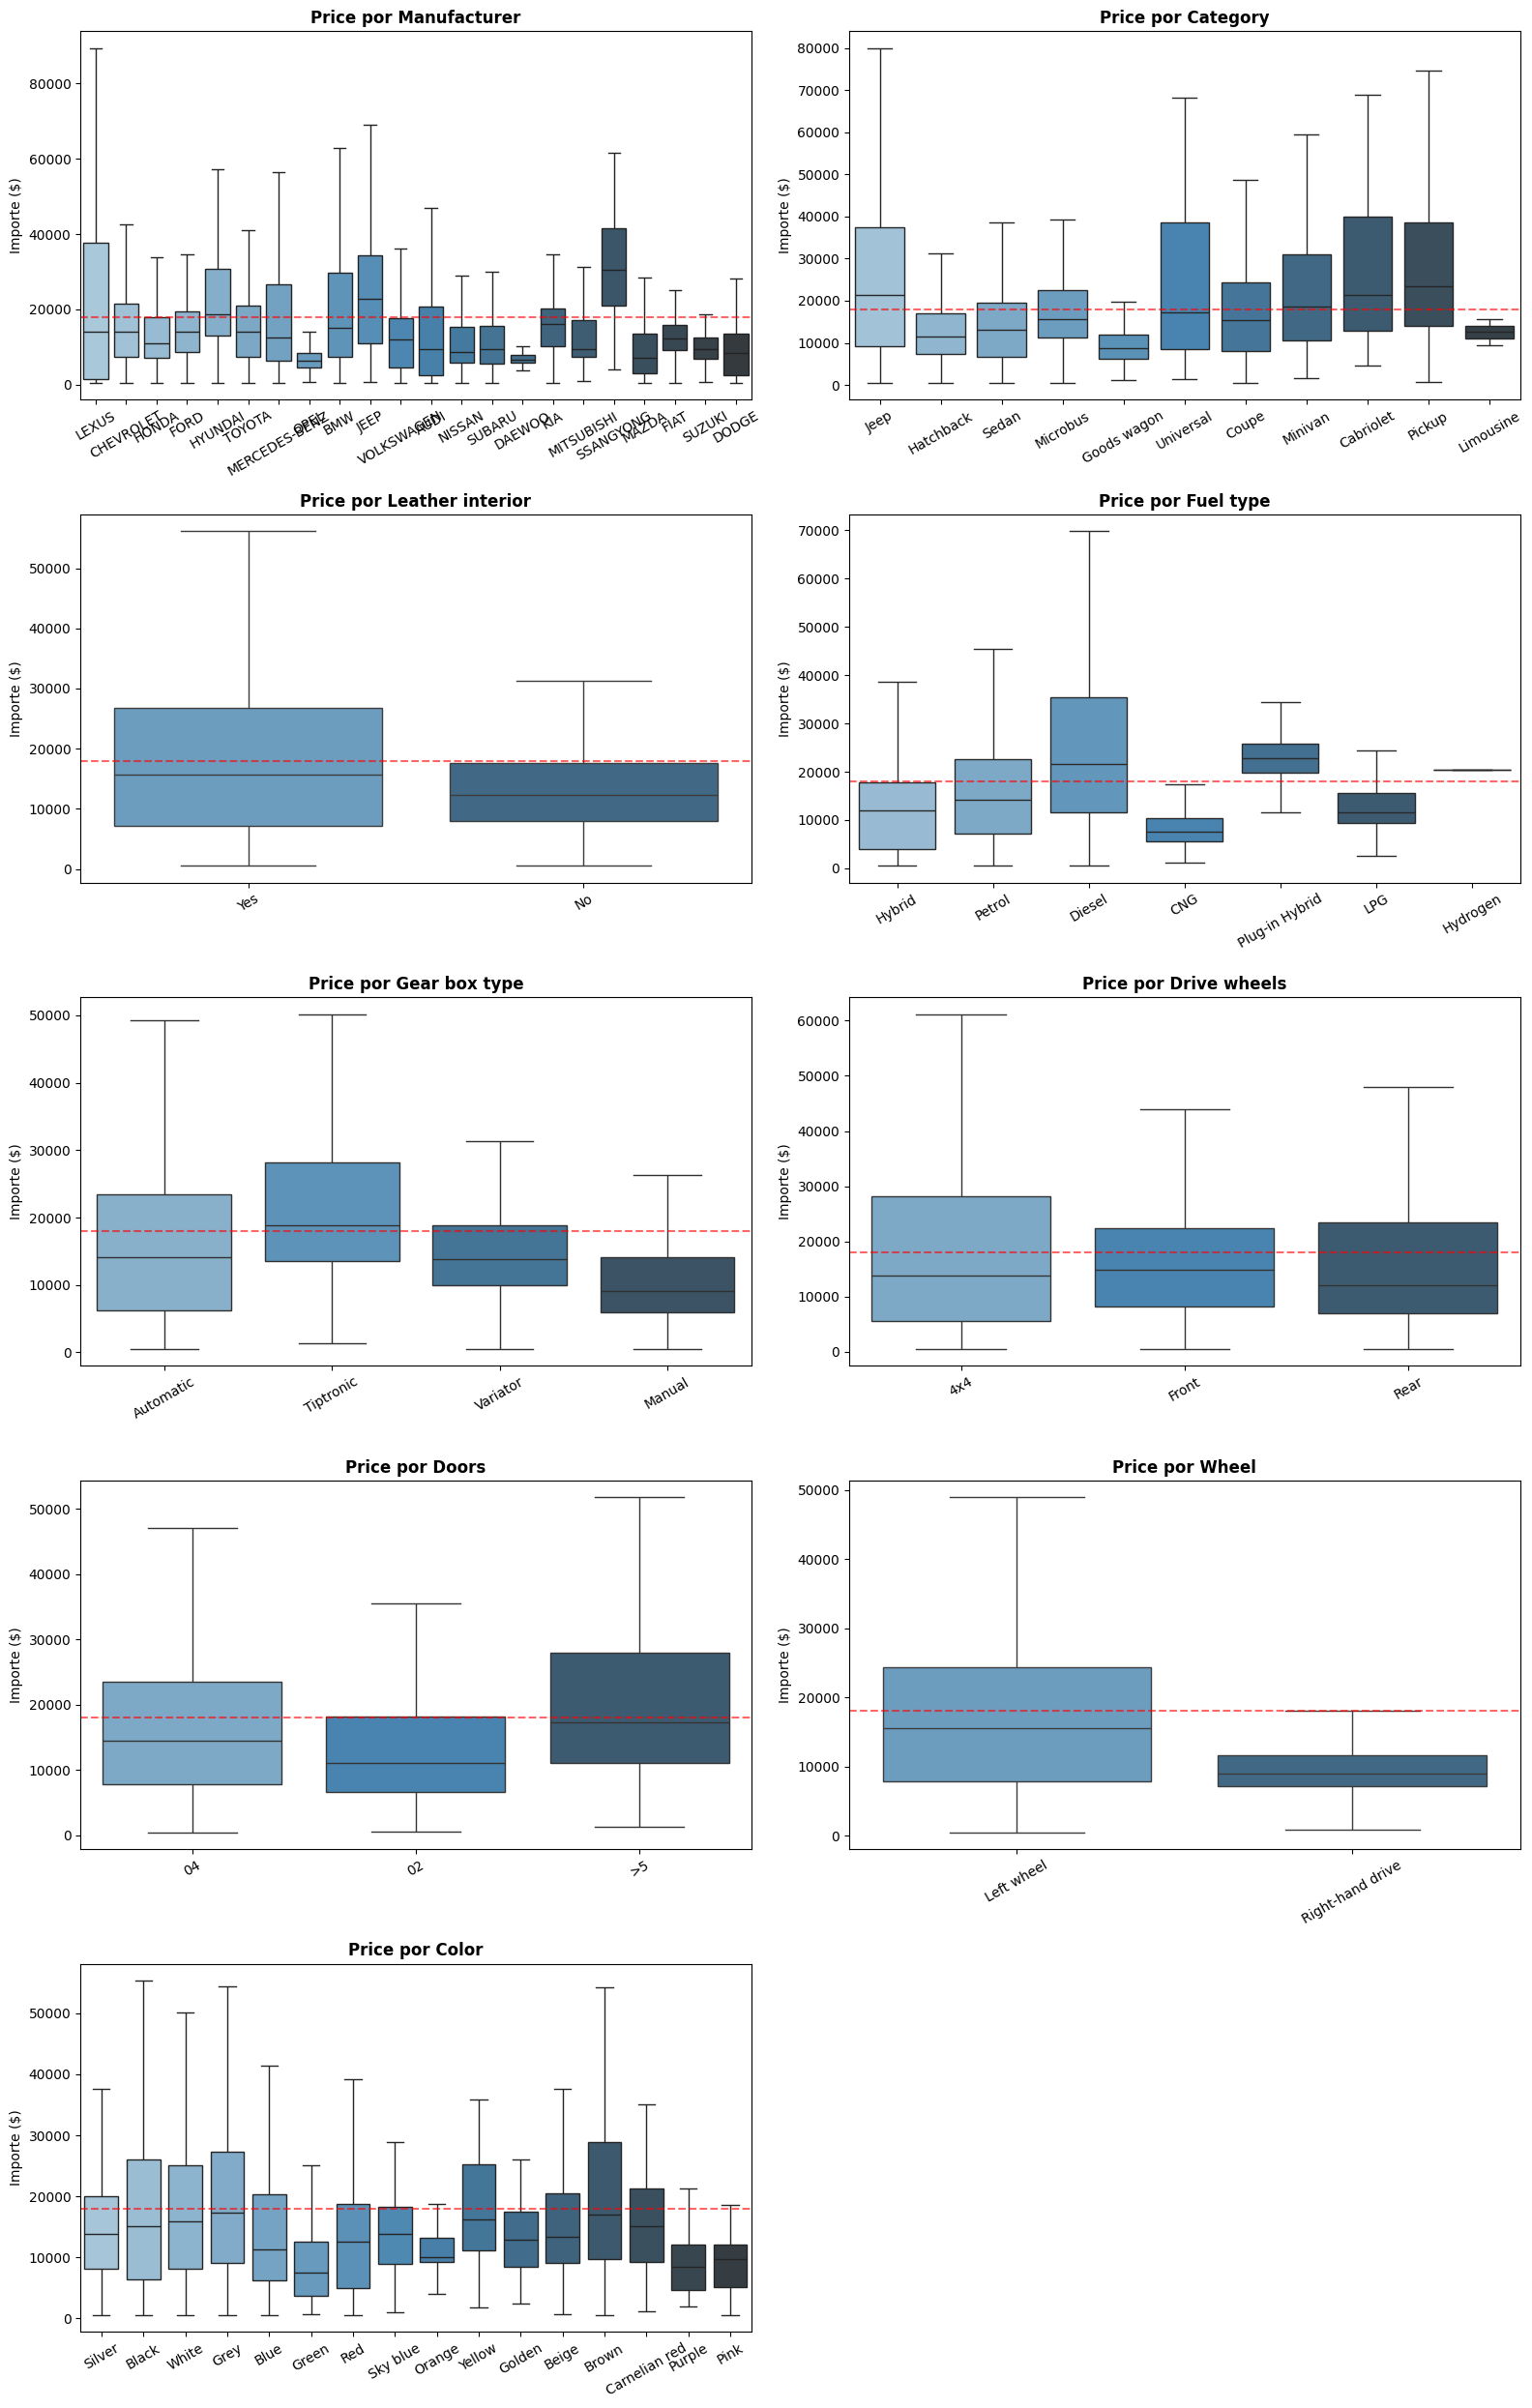

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos nuestras variables
target_reg = 'Price'  # Nuestra variable continua
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Configuramos la cuadrícula 5x2 (ajustar número de variables)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 25))
axes = axes.flatten()

for i, var in enumerate(cat_cols):
    if i < len(axes):
        # Creamos un boxplot para ver distribución, mediana y outliers
        sns.boxplot(
            data=df,
            x=var,
            y=target_reg,
            ax=axes[i],
            palette='Blues_d',
            showfliers=False  # Opcional: ocultar outliers para ver mejor la caja
        )

        # Añadimos una línea horizontal con la media global para comparar
        media_global = df[target_reg].mean()
        axes[i].axhline(media_global, color='red', linestyle='--', alpha=0.6, label='Media Global')

        axes[i].set_title(f'{target_reg} por {var}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Importe ($)')
        axes[i].tick_params(axis='x', rotation=30)

# Limpieza de espacios vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [47]:
dict_means =df.groupby('Color')['Price'].mean().to_dict()

In [48]:
dict_means

{'Beige': 16683.708333333332,
 'Black': 19125.509511803804,
 'Blue': 15849.038616251006,
 'Brown': 21603.129032258064,
 'Carnelian red': 16259.90243902439,
 'Golden': 14992.82142857143,
 'Green': 10058.22641509434,
 'Grey': 20557.054015296366,
 'Orange': 12042.004048582996,
 'Pink': 10627.130434782608,
 'Purple': 9967.129032258064,
 'Red': 14400.69190140845,
 'Silver': 16226.821386946387,
 'Sky blue': 14754.67857142857,
 'White': 19213.0487429451,
 'Yellow': 20781.666666666668}

In [49]:
df['Color_mean'] = df['Color'].map(dict_means)

In [50]:
df['Color'] = pd.qcut(df['Color_mean'], q=3, labels=['Bajo', 'Medio', 'Alto'])
df['Color'].value_counts()

Color
Medio    8545
Bajo     6061
Alto     2346
Name: count, dtype: int64

In [51]:
df.groupby('Color')['Price'].mean()

Color
Bajo     15428.993235
Medio    19076.153423
Alto     20635.646633
Name: Price, dtype: float64

In [52]:
# 1. Obtenemos el ranking de los fabricantes según su precio medio
dict_medias = df.groupby('Manufacturer')['Price'].mean().to_dict()

# 2. Creamos una nueva columna con el valor medio asignado a cada fila
df['Manufacturer_Mean'] = df['Manufacturer'].map(dict_medias)

# Agrupamos esos valores en 3 categorías: 'Bajo', 'Medio', 'Alto'
# Usamos qcut para que los grupos tengan un número similar de marcas
df['Manufacturer'] = pd.qcut(df['Manufacturer_Mean'], q=3, labels=['Low_Cost', 'Medium_Range', 'Premium']).astype(str)

# 4. Ahora puedes eliminar las columnas auxiliares
df = df.drop(columns=['Manufacturer_Mean'])

# Verificación final
agg_check = df.groupby('Manufacturer')['Price'].agg(['mean', 'count']).reset_index()
print(agg_check)

   Manufacturer          mean  count
0      Low_Cost  13965.114265   6975
1  Medium_Range  17934.400561   4993
2       Premium  23671.539326   4984


In [53]:
df = df.drop(columns=['Color_mean'])

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4868\4184930449.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4868\4184930449.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4868\4184930449.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is depre

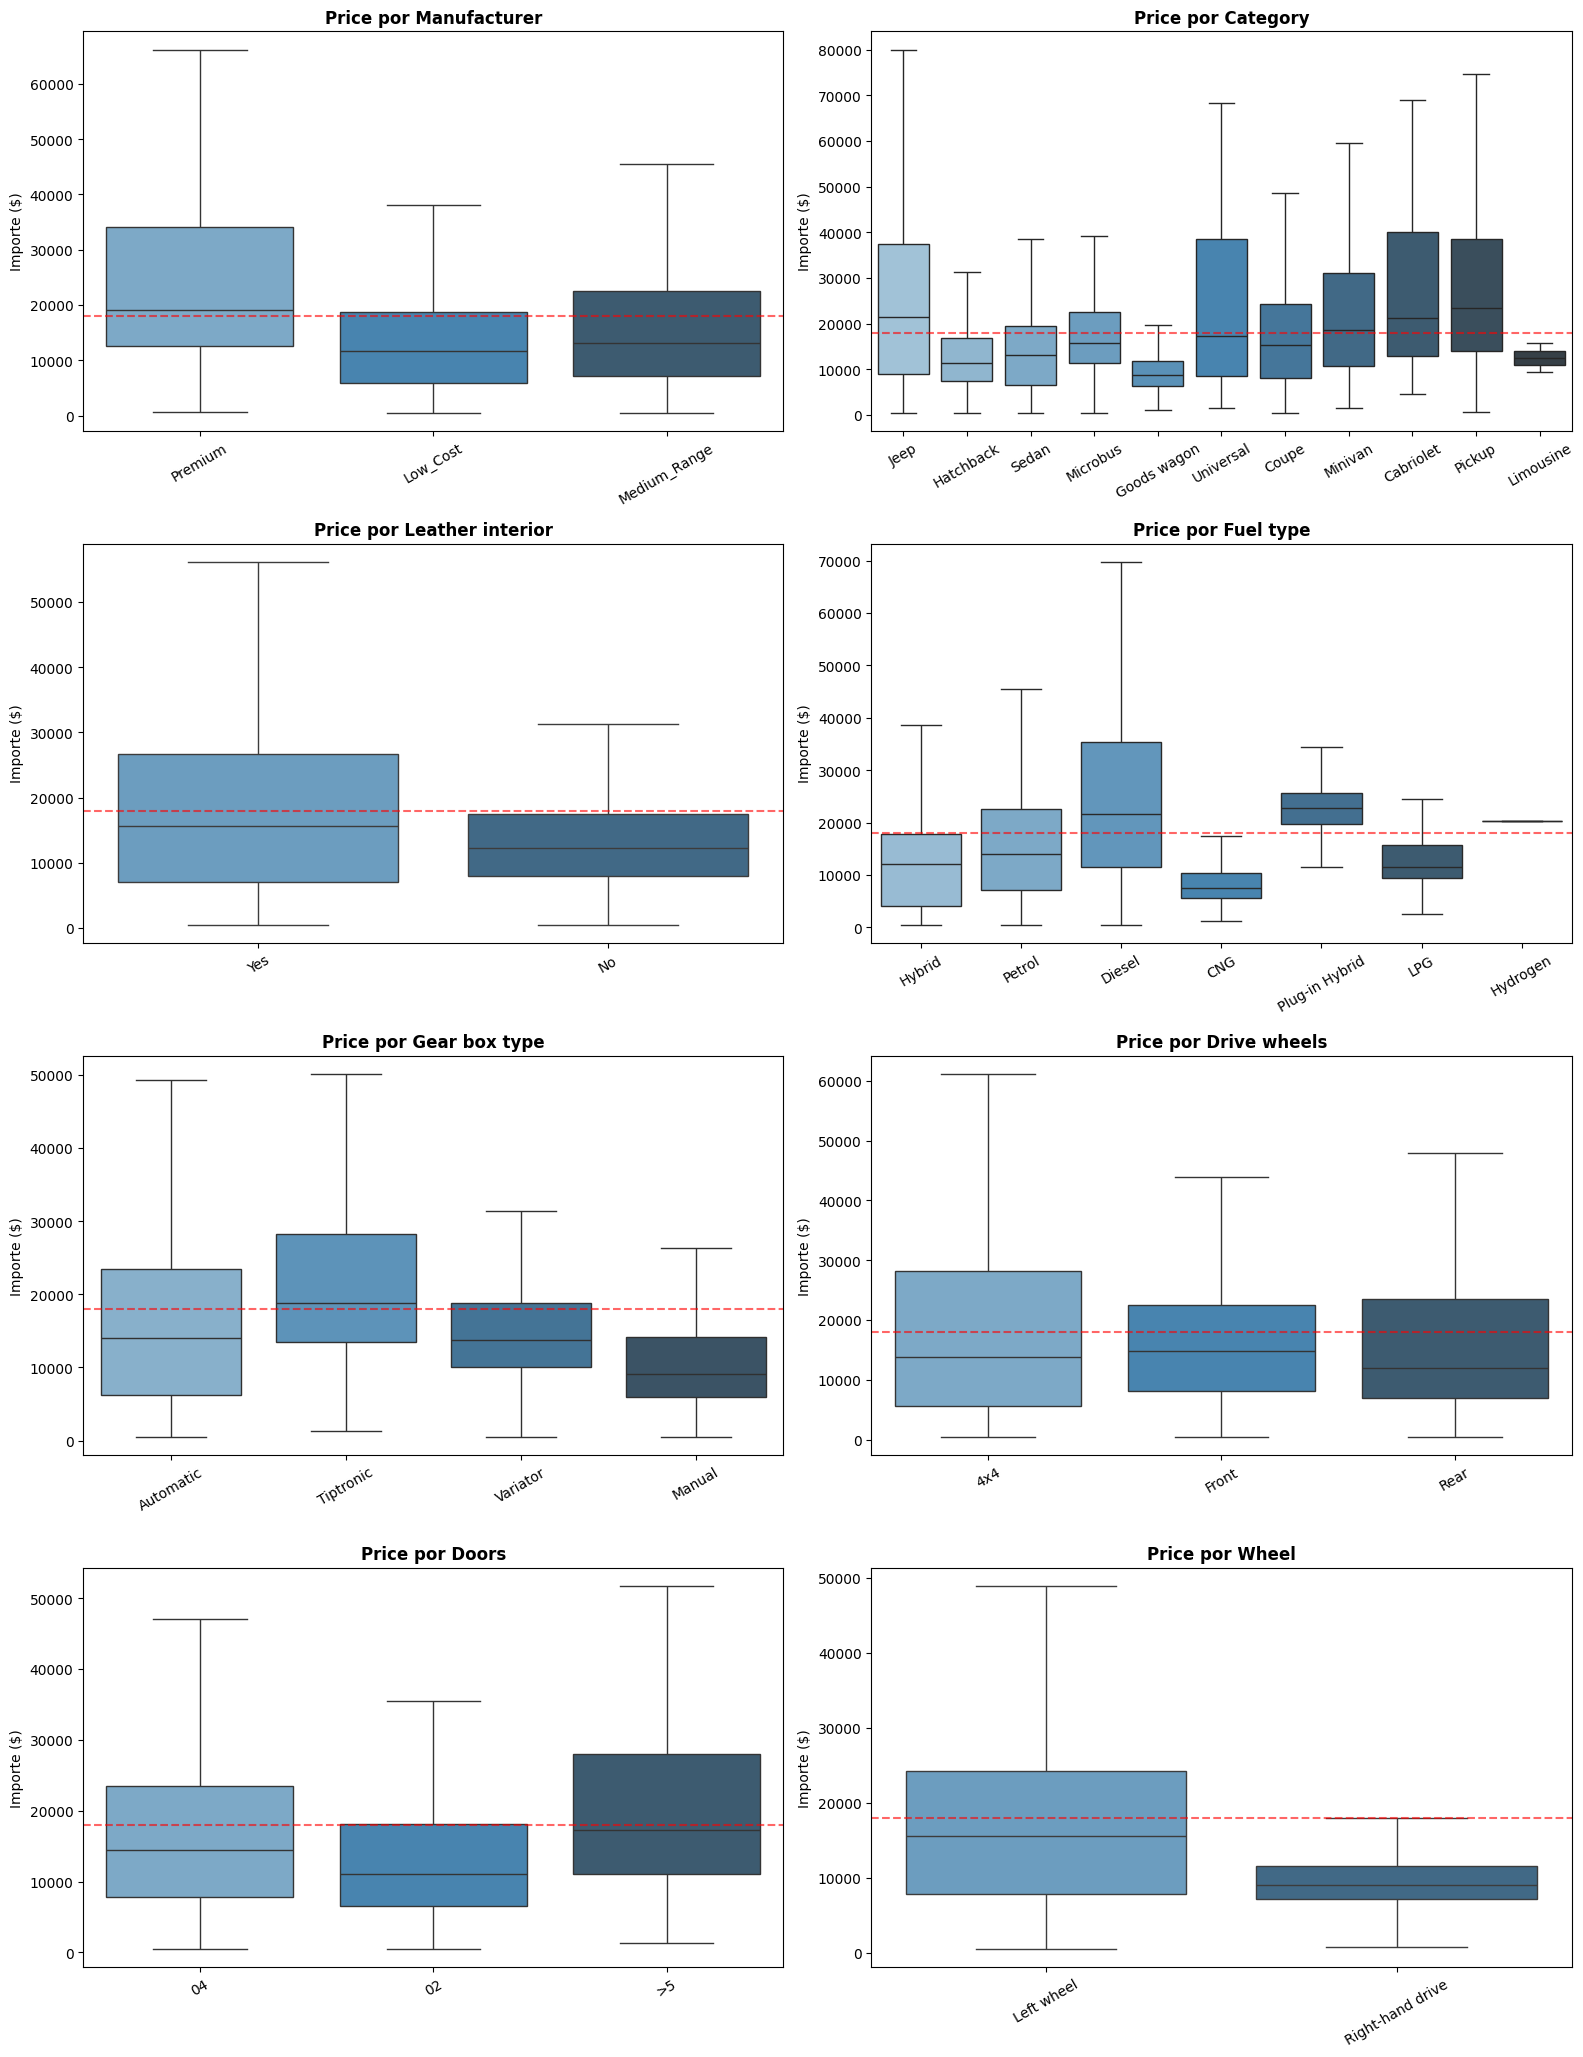

In [54]:
# Definimos nuestras variables
target_reg = 'Price'  # Nuestra variable continua
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Configuramos la cuadrícula 5x2 (ajustar número de variables)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 25))
axes = axes.flatten()

for i, var in enumerate(cat_cols):
    if i < len(axes):
        # Creamos un boxplot para ver distribución, mediana y outliers
        sns.boxplot(
            data=df,
            x=var,
            y=target_reg,
            ax=axes[i],
            palette='Blues_d',
            showfliers=False  # Opcional: ocultar outliers para ver mejor la caja
        )

        # Añadimos una línea horizontal con la media global para comparar
        media_global = df[target_reg].mean()
        axes[i].axhline(media_global, color='red', linestyle='--', alpha=0.6, label='Media Global')

        axes[i].set_title(f'{target_reg} por {var}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Importe ($)')
        axes[i].tick_params(axis='x', rotation=30)

# Limpieza de espacios vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [55]:
df['Color'].value_counts()

Color
Medio    8545
Bajo     6061
Alto     2346
Name: count, dtype: int64

> Se ha transformado en int64 al hacer qcut, no lo lee como categorica

In [56]:
df['Color'] = df['Color'].astype(str)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4868\4184930449.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4868\4184930449.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4868\4184930449.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is depre

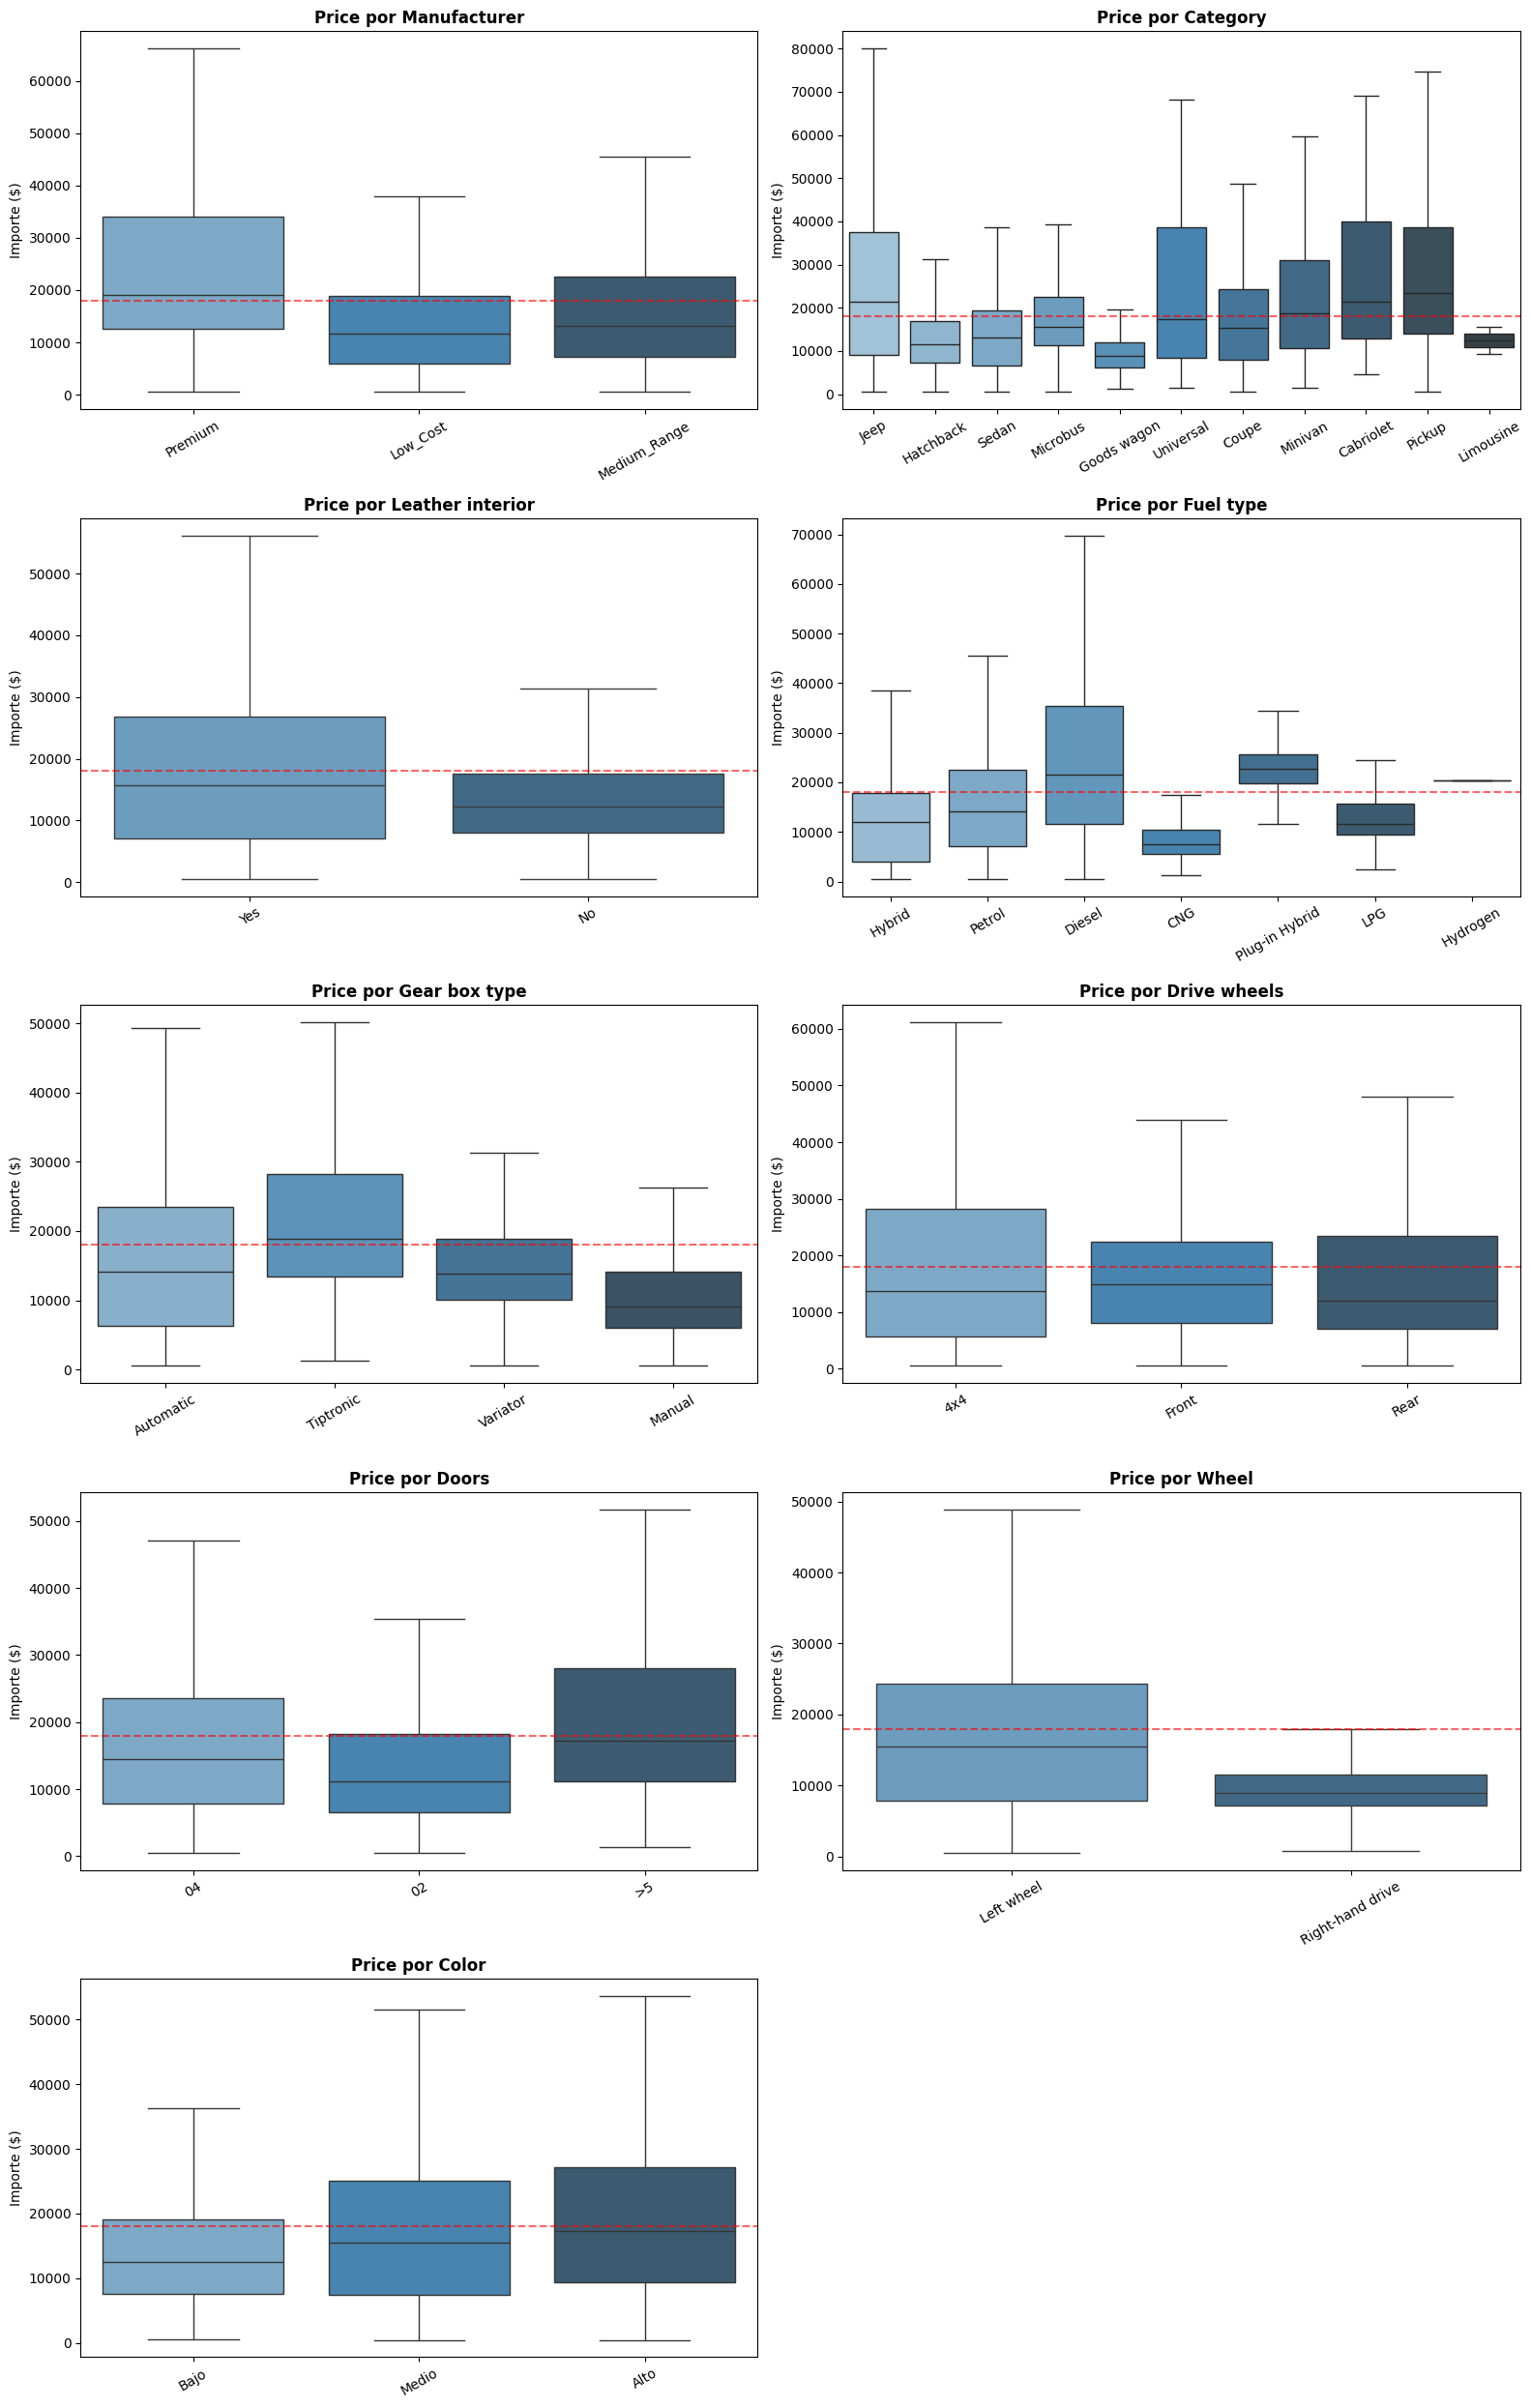

In [57]:
# Definimos nuestras variables
target_reg = 'Price'  # Nuestra variable continua
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Configuramos la cuadrícula 5x2 (ajustar número de variables)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 25))
axes = axes.flatten()

for i, var in enumerate(cat_cols):
    if i < len(axes):
        # Creamos un boxplot para ver distribución, mediana y outliers
        sns.boxplot(
            data=df,
            x=var,
            y=target_reg,
            ax=axes[i],
            palette='Blues_d',
            showfliers=False  # Opcional: ocultar outliers para ver mejor la caja
        )

        # Añadimos una línea horizontal con la media global para comparar
        media_global = df[target_reg].mean()
        axes[i].axhline(media_global, color='red', linestyle='--', alpha=0.6, label='Media Global')

        axes[i].set_title(f'{target_reg} por {var}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Importe ($)')
        axes[i].tick_params(axis='x', rotation=30)

# Limpieza de espacios vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<Axes: >

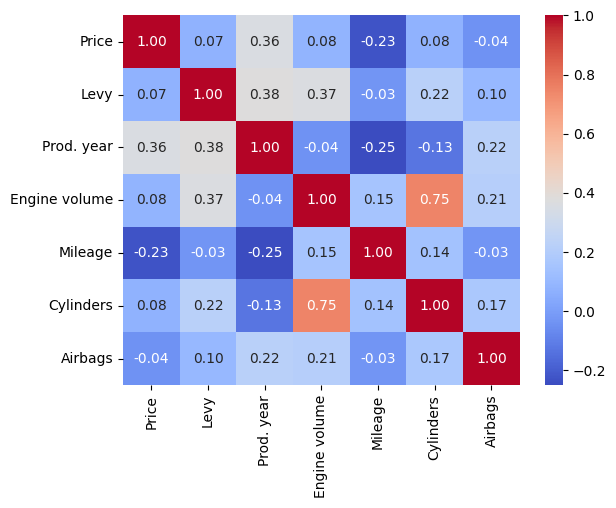

In [58]:
import seaborn as sns
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")

> Cilinders y Engine volume estan altamente correladas, una se puede eliminar. En función del Price, se puede observar que ambos estan coorreladas con Price con un 0.08 por lo que se puede eliminar cualquiera de las dos. Se ha decididio eliminar Engine volume. 

In [59]:
df.drop('Engine volume', axis=1, inplace=True, errors='ignore')

<Axes: >

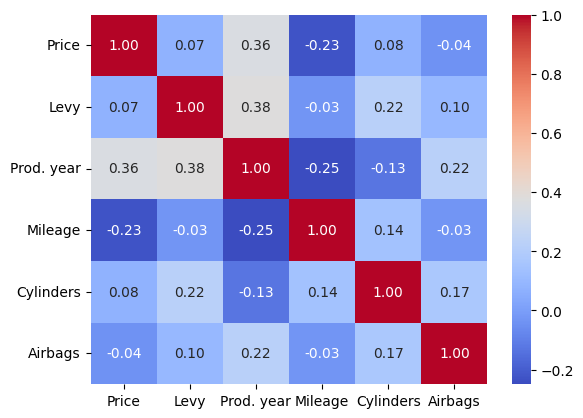

In [60]:
num_cols = df.select_dtypes(include="number").columns.tolist()
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")

In [61]:
X = df.drop('Price', axis=1)
y = df['Price']

In [62]:
from sklearn.model_selection import train_test_split    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=45)

In [63]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 11866 entries, 8226 to 7457
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Levy              11866 non-null  float64
 1   Manufacturer      11866 non-null  str    
 2   Prod. year        11866 non-null  int64  
 3   Category          11866 non-null  str    
 4   Leather interior  11866 non-null  str    
 5   Fuel type         11866 non-null  str    
 6   Mileage           11866 non-null  float64
 7   Cylinders         11866 non-null  float64
 8   Gear box type     11866 non-null  str    
 9   Drive wheels      11866 non-null  str    
 10  Doors             11866 non-null  str    
 11  Wheel             11866 non-null  str    
 12  Color             11866 non-null  str    
 13  Airbags           11866 non-null  int64  
dtypes: float64(3), int64(2), str(9)
memory usage: 1.4 MB


Escalar variables numericas al mismo rango

In [64]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols

['Price', 'Levy', 'Prod. year', 'Mileage', 'Cylinders', 'Airbags']

In [65]:
from sklearn.preprocessing import StandardScaler

num_cols_scaled = [col for col in num_cols if col in X_train.columns]

scaler = StandardScaler()
X_train[num_cols_scaled] = scaler.fit_transform(X_train[num_cols_scaled])
X_test[num_cols_scaled] = scaler.transform(X_test[num_cols_scaled])

In [66]:
X_train.describe()

,Levy,Prod. year,Mileage,Cylinders,Airbags
count,1.186600e+04,1.186600e+04,1.186600e+04,1.186600e+04,1.186600e+04
mean,3.592834e-17,1.862166e-14,1.455098e-16,-2.137736e-16,-3.173670e-17
std,1.000042e+00,1.000042e+00,1.000042e+00,1.000042e+00,1.000042e+00
min,-1.147644e+00,-8.483303e+00,-1.533680e+00,-3.050224e+00,-1.543419e+00
25%,-1.147644e+00,-3.574209e-01,-7.234519e-01,-4.585238e-01,-5.876122e-01
50%,3.359855e-02,1.966165e-01,-1.082268e-01,-4.585238e-01,-5.876122e-01
75%,4.917440e-01,7.506539e-01,5.774768e-01,-4.585238e-01,1.324000e+00
max,2.040543e+01,1.674050e+00,4.172148e+00,9.908278e+00,2.279807e+00


In [67]:
X_test.describe()

,Levy,Prod. year,Mileage,Cylinders,Airbags
count,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000
mean,0.008247,0.010194,0.024780,0.006888,-0.010013
std,1.074534,0.992166,1.010910,0.993851,0.996868
min,-1.147644,-8.483303,-1.533680,-3.050224,-1.543419
25%,-1.147644,-0.357421,-0.717401,-0.458524,-0.587612
50%,0.033599,0.196617,-0.084262,-0.458524,-0.587612
75%,0.491744,0.750654,0.583559,-0.458524,1.324000
max,20.405430,1.674050,4.172148,9.908278,2.279807


In [68]:
cat_cols = df.select_dtypes(include=[object]).columns.tolist()
cat_cols


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4868\2523723416.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=[object]).columns.tolist()


['Manufacturer',
 'Category',
 'Leather interior',
 'Fuel type',
 'Gear box type',
 'Drive wheels',
 'Doors',
 'Wheel',
 'Color']

In [69]:
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

In [70]:
X_train.head()

,Levy,Prod. year,Mileage,Cylinders,Airbags,Manufacturer_Medium_Range,Manufacturer_Premium,Category_Coupe,Category_Goods wagon,Category_Hatchback,...,Gear box type_Manual,Gear box type_Tiptronic,Gear box type_Variator,Drive wheels_Front,Drive wheels_Rear,Doors_04,Doors_>5,Wheel_Right-hand drive,Color_Bajo,Color_Medio
8226,0.153195,0.011937,2.193504,-0.458524,-0.587612,False,True,False,False,False,...,False,False,False,True,False,True,False,False,False,True
3604,0.281991,0.565975,0.583559,-0.458524,-1.543419,False,False,False,False,False,...,False,False,False,True,False,True,False,False,True,False
13812,-0.323350,0.196617,2.132532,-0.458524,-1.543419,True,False,False,False,True,...,False,False,False,True,False,True,False,False,True,False
11327,0.381347,0.011937,1.026514,-0.458524,-1.543419,False,True,False,False,False,...,False,False,False,True,False,True,False,False,False,False
4686,0.390547,-0.172742,0.517760,-0.458524,-0.587612,False,True,False,False,False,...,False,False,False,True,False,True,False,False,False,False


In [71]:
X_test.head()

,Levy,Prod. year,Mileage,Cylinders,Airbags,Manufacturer_Medium_Range,Manufacturer_Premium,Category_Coupe,Category_Goods wagon,Category_Hatchback,...,Gear box type_Manual,Gear box type_Tiptronic,Gear box type_Variator,Drive wheels_Front,Drive wheels_Rear,Doors_04,Doors_>5,Wheel_Right-hand drive,Color_Bajo,Color_Medio
3484,-0.498145,0.750654,0.005011,-0.458524,1.324000,False,False,False,False,True,...,False,False,False,True,False,True,False,False,False,False
10126,0.390547,-0.172742,0.915707,-0.458524,-0.587612,False,True,False,False,False,...,False,False,False,True,False,True,False,False,False,True
5497,0.570861,0.750654,-0.985920,-0.458524,-0.109709,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
12002,-1.147644,0.011937,-0.130046,-0.458524,-0.587612,True,False,False,False,True,...,False,False,False,True,False,True,False,True,True,False
16380,0.029919,0.381296,-0.199452,-0.458524,-0.587612,False,True,False,False,False,...,False,False,False,True,False,True,False,False,False,True


In [72]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [73]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [74]:
predictions = model.predict(X_test)
predictions[:4]

array([12738.25039077, 23874.56648865, 24979.58946334, 11070.35533523])

In [75]:
from sklearn import metrics
print('MAE (Error Absoluto Medio):', metrics.mean_absolute_error(y_test, predictions))
print('MSE (Error Cuadrático Medio):', metrics.mean_squared_error(y_test, predictions))
print('RMSE (Raíz del Error Cuadrático Medio):', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('R2 (Coeficiente de Determinación):', metrics.r2_score(y_test, predictions))

MAE (Error Absoluto Medio): 8580.663409386772
MSE (Error Cuadrático Medio): 148740977.4535549
RMSE (Raíz del Error Cuadrático Medio): 12195.941023699437
R2 (Coeficiente de Determinación): 0.35554180569191507


In [76]:
print(f"Intercercepción (Beta 0): {model.intercept_:.2f}")
coeff_df = pd.DataFrame(model.coef_, X_train.columns, columns=['Coeficiente'])
print(coeff_df.sort_values(by='Coeficiente', ascending=False))

Intercercepción (Beta 0): 24545.86
                            Coeficiente
Category_Limousine          9322.956091
Gear box type_Tiptronic     8863.953007
Prod. year                  7264.112618
Fuel type_Plug-in Hybrid    6627.409322
Doors_>5                    6312.034641
Gear box type_Variator      5702.401809
Gear box type_Manual        5518.175758
Manufacturer_Premium        4591.520223
Drive wheels_Rear           3383.629937
Fuel type_Diesel            3185.966916
Doors_04                    3125.782853
Cylinders                   1796.975264
Manufacturer_Medium_Range   1363.517951
Drive wheels_Front           599.775830
Color_Medio                 -450.250637
Leather interior_Yes        -514.305056
Fuel type_Petrol            -706.050100
Category_Pickup            -1345.861267
Color_Bajo                 -1503.253451
Mileage                    -1962.947589
Airbags                    -1977.802742
Levy                       -1979.524175
Wheel_Right-hand drive     -2007.946386
Fuel 

> El coeficiente beta asociado a cada variable del dataset indica por ejemplo, en las limusionas tiene un impacto de 9000 euros, es decir, el precio estimado sera 9000 euros mas alto. Prod year es positivo, por lo que a mayor año, el precio del vehiculo será más caro. Se puede observar que la variable Doors, a mayor número de puertas encarece más el precio del vehiculo, lo que es lógico. Los microbuses y los Goods_wagon son los vehiculos más rebajados.

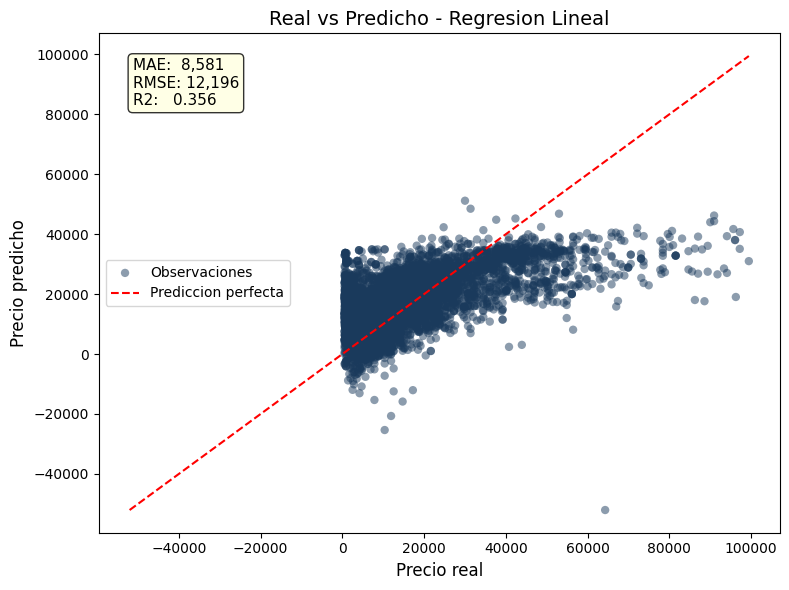

In [77]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics

mae  = metrics.mean_absolute_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
r2   = metrics.r2_score(y_test, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, predictions, alpha=0.5, color='#1a3a5c', edgecolors='none', label='Observaciones')
lims = [min(y_test.min(), predictions.min()), max(y_test.max(), predictions.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Prediccion perfecta')
texto = 'MAE:  {:,.0f}\nRMSE: {:,.0f}\nR2:   {:.3f}'.format(mae, rmse, r2)
ax.text(0.05, 0.95, texto, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.set_xlabel('Precio real', fontsize=12)
ax.set_ylabel('Precio predicho', fontsize=12)
ax.set_title('Real vs Predicho - Regresion Lineal', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()


>Se puede observar que el modelo capta cierta relación directa pero no lo hace con la tendencia que debería. El modelo sobrestima el precio de los coches baratos e infraestima el precio de los coches caros, esto puede deberse a que el modelo no tiene la capacidad predictiva suficinete para determinar como afectan las distntas variables al precio, es como si estuviesemos asumiendo que el modelo es lineal cuando no lo es. También asume precios negativos, lo cual es claro indicador que el modelo es sencillo para el caso y se debería usar un modelo más complejo.

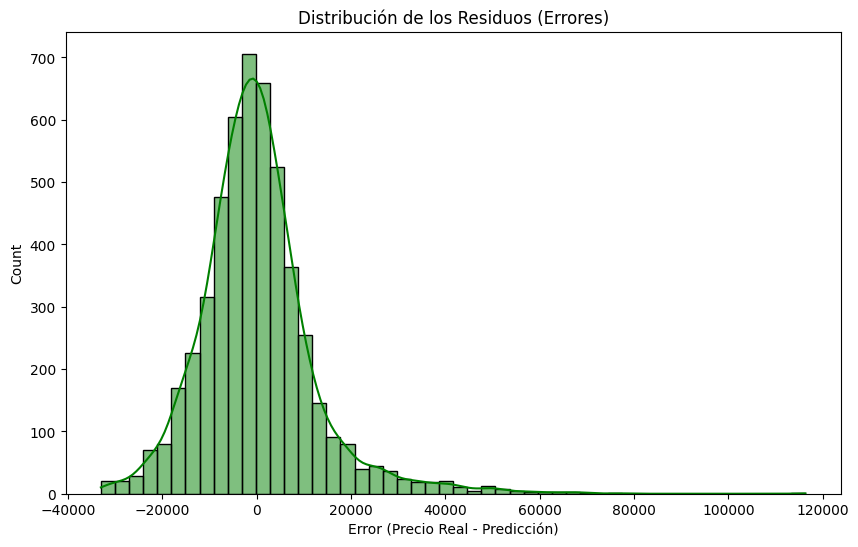

In [78]:
plt.figure(figsize=(10, 6))
sns.histplot((y_test - predictions), bins=50, kde=True, color='green')
plt.title('Distribución de los Residuos (Errores)')
plt.xlabel('Error (Precio Real - Predicción)')
plt.show()

Modelos más complejos -- Arbol de decisiones y RandomForest

In [79]:
from sklearn.tree import DecisionTreeRegressor
tree_regs= DecisionTreeRegressor(max_depth=5,random_state=42)
tree_regs.fit(X_train, y_train)

tree_preds = tree_regs.predict(X_test) 

In [80]:
tree_preds[:4]

array([ 9003.97527273, 20663.54561717, 16356.28431373, 15435.66086187])

In [81]:
print('MAE', metrics.mean_absolute_error(y_test, tree_preds))
print('MSE', metrics.mean_squared_error(y_test, tree_preds))
print('R2 Score', metrics.r2_score(y_test, tree_preds))

MAE 7743.666870090255
MSE 130146927.69211109
R2 Score 0.4361052653335362


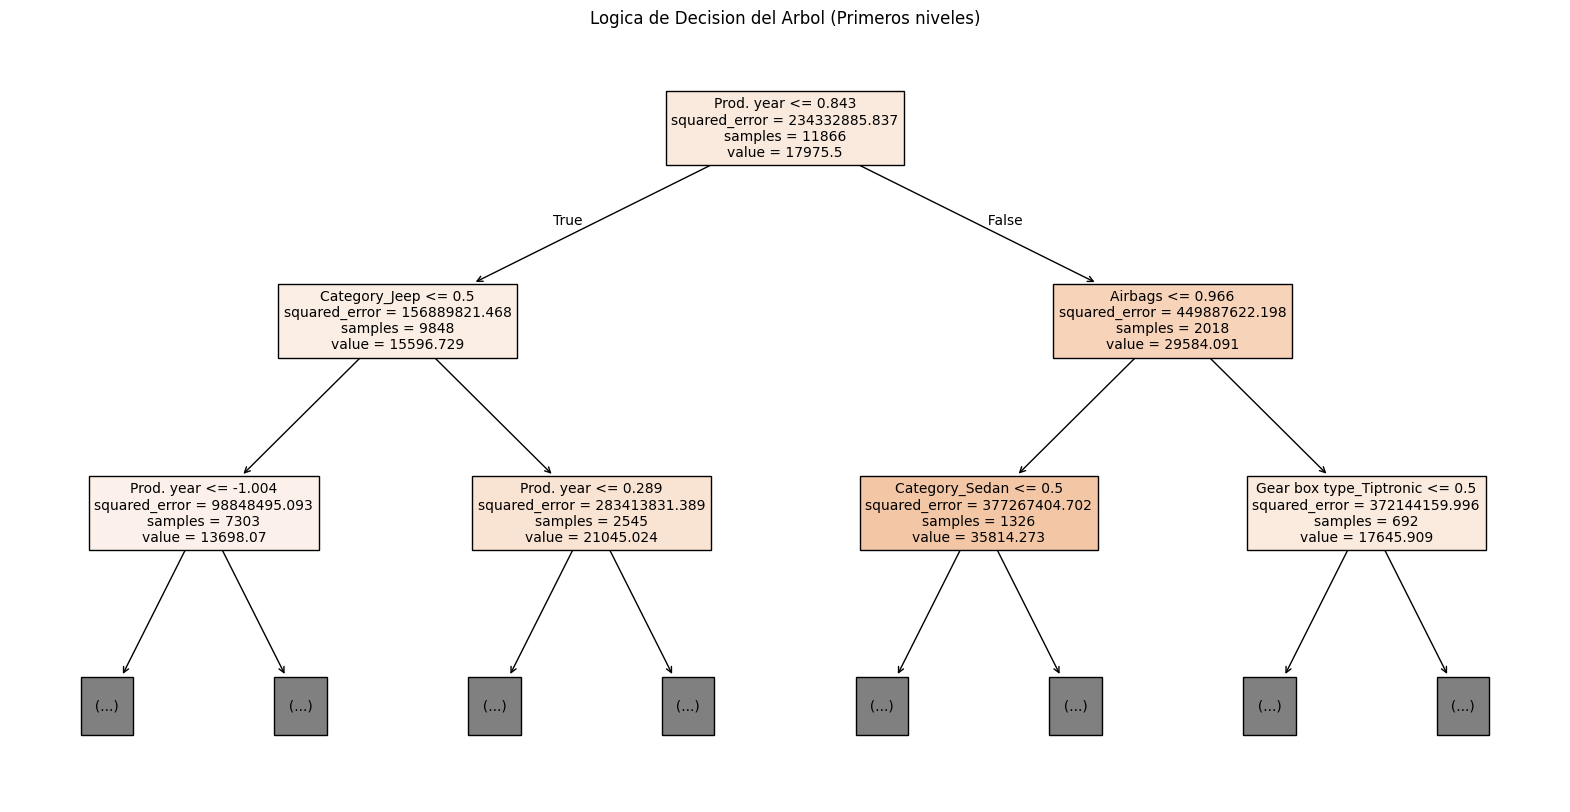

In [82]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

tree_regs = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_regs.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(tree_regs,
          feature_names=X_train.columns,
          filled=True,
          fontsize=10,
          max_depth=2)
plt.title('Logica de Decision del Arbol (Primeros niveles)')
plt.show()


In [83]:
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import numpy as np

# 1. Instanciar el modelo
# n_estimators=100: Número de árboles en el bosque
# n_jobs=-1: Utiliza todos los procesadores de tu PC para ir más rápido
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Ajustar el modelo
rf_reg.fit(X_train, y_train)

# 3. Predicciones
rf_preds = rf_reg.predict(X_test)
rf_preds[:4]   

array([ 3767.68, 17841.89, 35651.91, 12229.39])

In [84]:
print('--- DIAGNOSIS: RANDOM FOREST ---')
print('MAE (Error medio):', metrics.mean_absolute_error(y_test, rf_preds))
print('RMSE (Raíz del error cuadrático):', np.sqrt(metrics.mean_squared_error(y_test, rf_preds)))
print('R2 Score (Varianza explicada):', metrics.r2_score(y_test, rf_preds))

--- DIAGNOSIS: RANDOM FOREST ---
MAE (Error medio): 4082.0198145779896
RMSE (Raíz del error cuadrático): 7305.157923002813
R2 Score (Varianza explicada): 0.7687810967185174


> Se captura el 77% aprox de toda la muestra como determina el R2, sin embargo, el modelo RandomForest no deja tan claro la interpretabilidad

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4868\423802731.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias.head(15), x='Importancia', y='Variable', palette='magma')


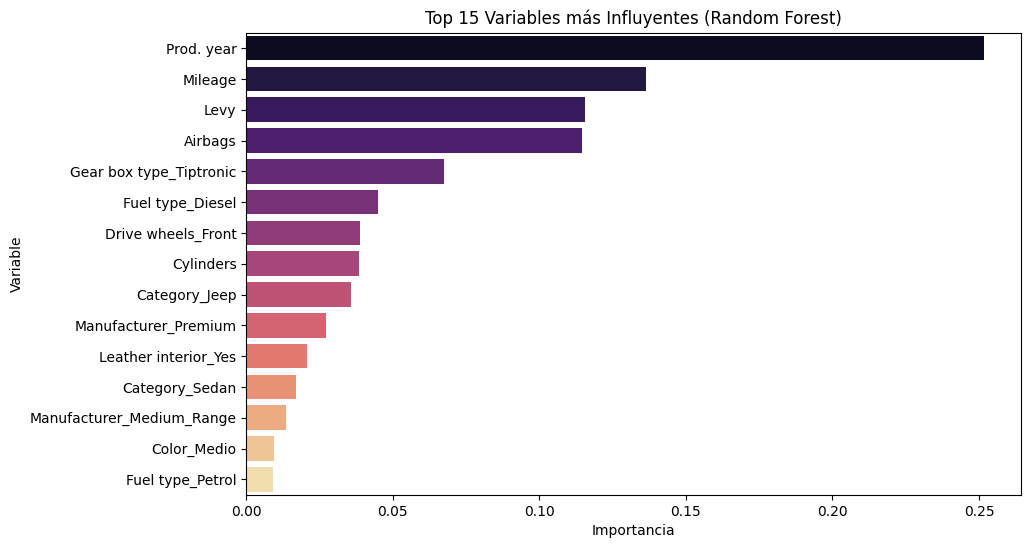

In [85]:
# Visualización de la Importancia de las Variables

# Extraer las importancias
importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf_reg.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Graficar las 15 más importantes
plt.figure(figsize=(10, 6))
sns.barplot(data=importancias.head(15), x='Importancia', y='Variable', palette='magma')
plt.title('Top 15 Variables más Influyentes (Random Forest)')
plt.show()

> Aquí se muestra las variables que más influyen en el precio, como es logico y como se ha vsito en los modelos anteriores, el año de producción influye mayormente al precio del vehículo.

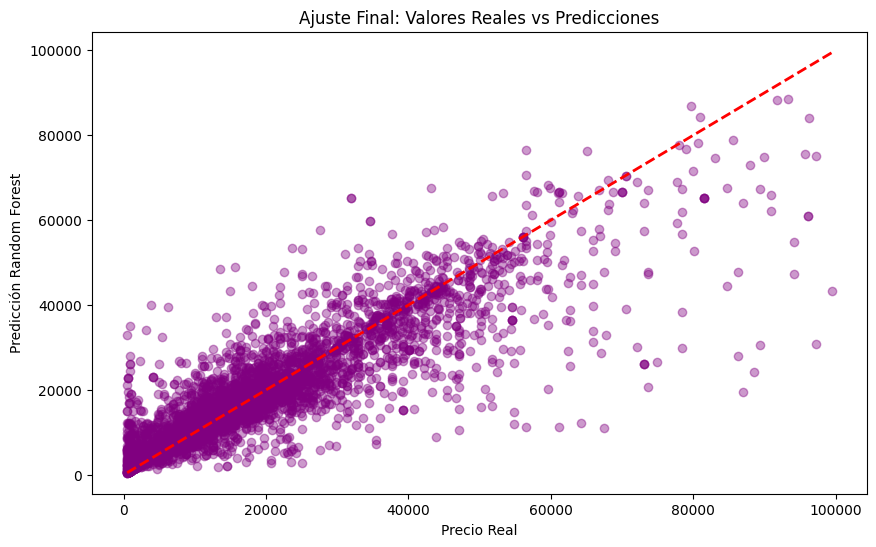

In [86]:
# Representacion gráfica de los resultados
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_preds, alpha=0.4, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Precio Real')
plt.ylabel('Predicción Random Forest')
plt.title('Ajuste Final: Valores Reales vs Predicciones')
plt.show()

> El modelo sigue la tendencia, se obtienen mejores resultados por lo que es más correto

XGBoost

In [87]:
from xgboost import XGBRegressor
from sklearn import metrics

# Instanciar el modelo
# learning_rate: paso de aprendizaje (0.01 a 0.3 es lo habitual)
# max_depth: profundidad de cada árbol secuencial
xgb_reg = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42)

# Ajustar el modelo
# Usamos early_stopping para que el modelo deje de entrenar si deja de mejorar
xgb_reg.fit(X_train, y_train, 
            eval_set=[(X_test, y_test)], 
            verbose=False)

# Predicciones
xgb_preds = xgb_reg.predict(X_test)

In [88]:
xgb_preds[:4]

array([ 3921.2617, 19513.7   , 38923.844 , 11080.388 ], dtype=float32)

In [89]:
print('MAE (Error Absoluto Medio):', metrics.mean_absolute_error(y_test, xgb_preds))
print('MSE (Error Cuadrático Medio):', metrics.mean_squared_error(y_test, xgb_preds))
print('RMSE (Raíz del Error Cuadrático Medio):', np.sqrt(metrics.mean_squared_error(y_test, xgb_preds)))
print('R2 (Coeficiente de Determinación):', metrics.r2_score(y_test, xgb_preds))


MAE (Error Absoluto Medio): 4417.87255859375
MSE (Error Cuadrático Medio): 55104024.0
RMSE (Raíz del Error Cuadrático Medio): 7423.208470735549
R2 (Coeficiente de Determinación): 0.7612477540969849


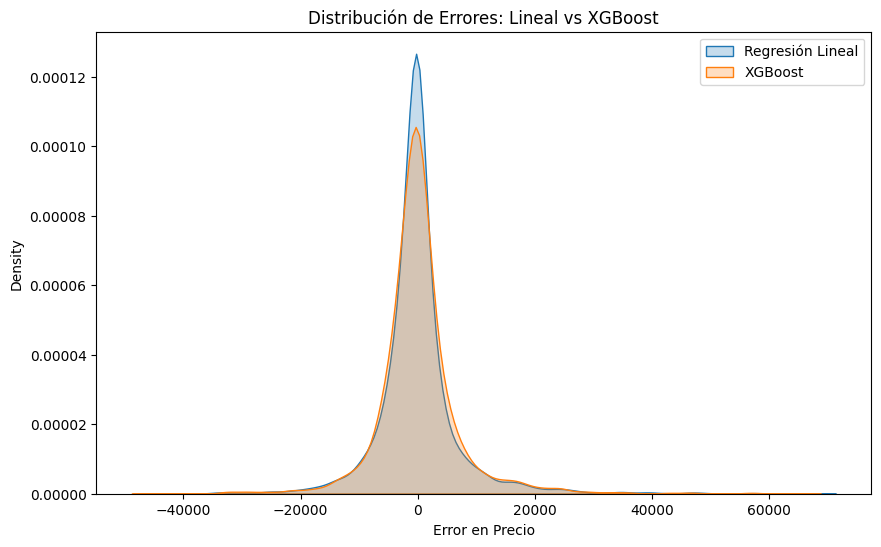

In [90]:
plt.figure(figsize=(10, 6))
sns.kdeplot(y_test - rf_preds, label='Regresión Lineal', fill=True)
sns.kdeplot(y_test - xgb_preds, label='XGBoost', fill=True)
plt.title('Distribución de Errores: Lineal vs XGBoost')
plt.xlabel('Error en Precio')
plt.legend()
plt.show()

> XGBoost tiene menor dendidad concentrada al rededor del 0 por lo que es un peor modelo en este caso que la Regresión Lineal.

<Figure size 1200x800 with 0 Axes>

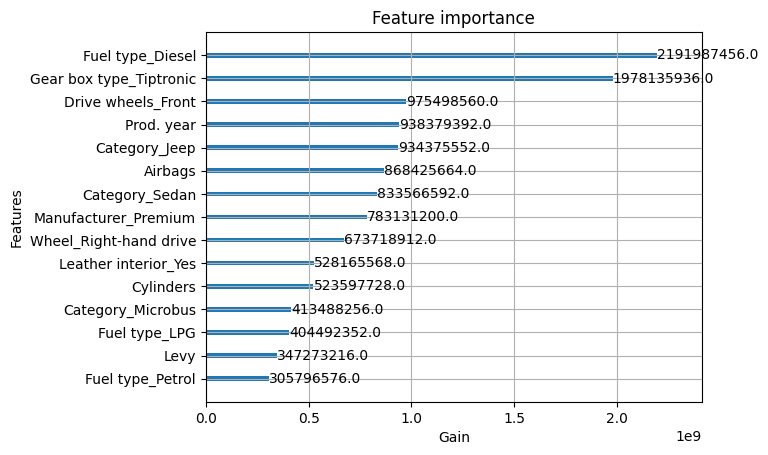

In [91]:
from xgboost import plot_importance

plt.figure(figsize=(12, 8))
plot_importance(xgb_reg, max_num_features=15, importance_type='gain', xlabel='Gain')
plt.show()

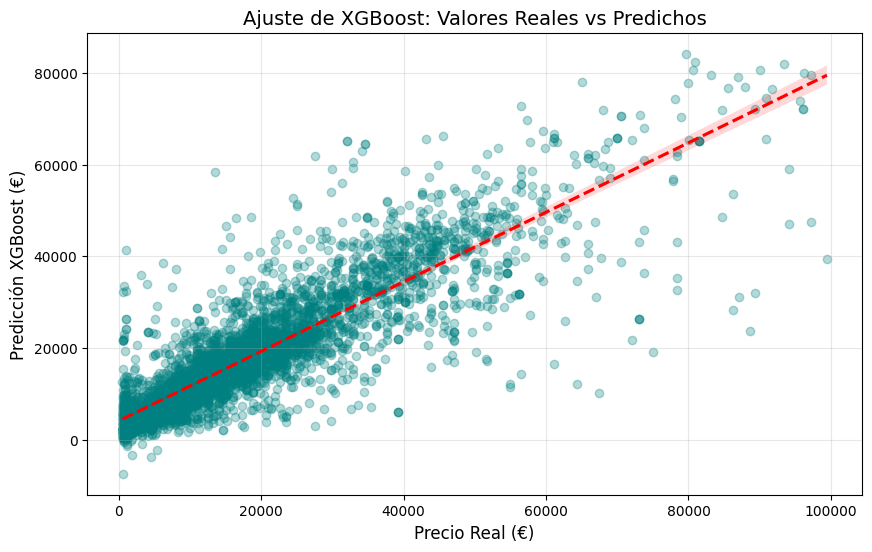

In [92]:
plt.figure(figsize=(10, 6))
# Los puntos deben seguir la diagonal roja
sns.regplot(x=y_test, y=xgb_preds, scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red', 'ls':'--'})

plt.title('Ajuste de XGBoost: Valores Reales vs Predichos', fontsize=14)
plt.xlabel('Precio Real (€)', fontsize=12)
plt.ylabel('Predicción XGBoost (€)', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

Optimización XGBoost (GridSearch)

In [93]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# 1. Definimos el modelo base
xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

# 2. Definimos la malla de parámetros (Grid)
# Nota: Empieza con pocos valores para que no tarde demasiado
param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 500, 1000],
    'subsample': [0.8, 1.0]
}

# 3. Configuramos el GridSearchCV
# scoring='neg_mean_absolute_error': queremos minimizar el error
# cv=3: validación cruzada de 3 carpetas para ahorrar tiempo
grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2
)

# 4. Ajustamos el modelo (este paso puede llevar varios minutos)
grid_xgb.fit(X_train, y_train)

# 5. Mejores resultados
print("Mejores parámetros encontrados:")
print(grid_xgb.best_params_)

# 6. Modelo final optimizado
best_xgb = grid_xgb.best_estimator_

Fitting 3 folds for each of 54 candidates, totalling 162 fits
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.8; total time=   0.4s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.8; total time=   0.4s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.8; total time=   0.4s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=500, subsample=1.0; total time=   0.3

In [94]:
# Predicciones con el mejor modelo
best_preds = best_xgb.predict(X_test)

# Métricas finales
print('--- XGBOOST OPTIMIZADO ---')
print('MAE:', metrics.mean_absolute_error(y_test, best_preds))
print('R2 Score:', metrics.r2_score(y_test, best_preds))

--- XGBOOST OPTIMIZADO ---
MAE: 4070.895751953125
R2 Score: 0.7712202072143555


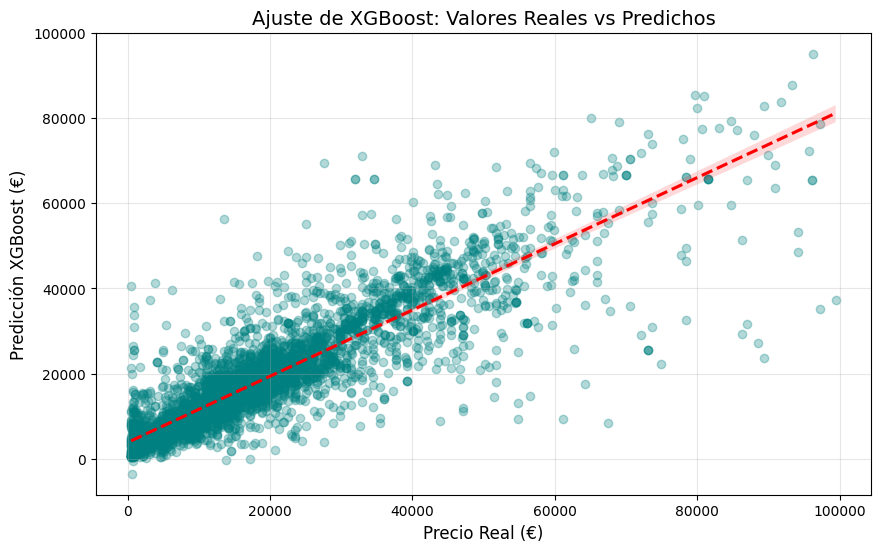

In [95]:
plt.figure(figsize=(10, 6))
# Los puntos deben seguir la diagonal roja
sns.regplot(x=y_test, y=best_preds, scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red', 'ls':'--'})

plt.title('Ajuste de XGBoost: Valores Reales vs Predichos', fontsize=14)
plt.xlabel('Precio Real (€)', fontsize=12)
plt.ylabel('Predicción XGBoost (€)', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In [96]:
print("REGRESION LINEAL:")
print('MAE (Error medio):', metrics.mean_absolute_error(y_test, predictions))
print('RMSE (Raiz del error cuadratico):', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('R2 Score (Varianza explicada):', metrics.r2_score(y_test, predictions))

print("\nRANDOM FOREST:")
print('MAE (Error medio):', metrics.mean_absolute_error(y_test, rf_preds))
print('RMSE (Raiz del error cuadratico):', np.sqrt(metrics.mean_squared_error(y_test, rf_preds)))
print('R2 Score (Varianza explicada):', metrics.r2_score(y_test, rf_preds))

print("\nXGBOOST:")
print('MAE (Error medio):', metrics.mean_absolute_error(y_test, best_preds))
print('RMSE (Raiz del error cuadratico):', np.sqrt(metrics.mean_squared_error(y_test, best_preds)))
print('R2 Score (Varianza explicada):', metrics.r2_score(y_test, best_preds))


REGRESION LINEAL:
MAE (Error medio): 8580.663409386772
RMSE (Raiz del error cuadratico): 12195.941023699437
R2 Score (Varianza explicada): 0.35554180569191507

RANDOM FOREST:
MAE (Error medio): 4082.0198145779896
RMSE (Raiz del error cuadratico): 7305.157923002813
R2 Score (Varianza explicada): 0.7687810967185174

XGBOOST:
MAE (Error medio): 4070.895751953125
RMSE (Raiz del error cuadratico): 7266.5251668180435
R2 Score (Varianza explicada): 0.7712202072143555


> Por lo tanto, el modelo que más se adecua es el XGBoost y en segundo lugar el Random Forest, ya que los resultados indican que el error se ha reducido a la mitad, obteniendo una correlación del 77 y 76%.

K-Means

In [97]:
X = df.drop('Price', axis=1)
y = df['Price']

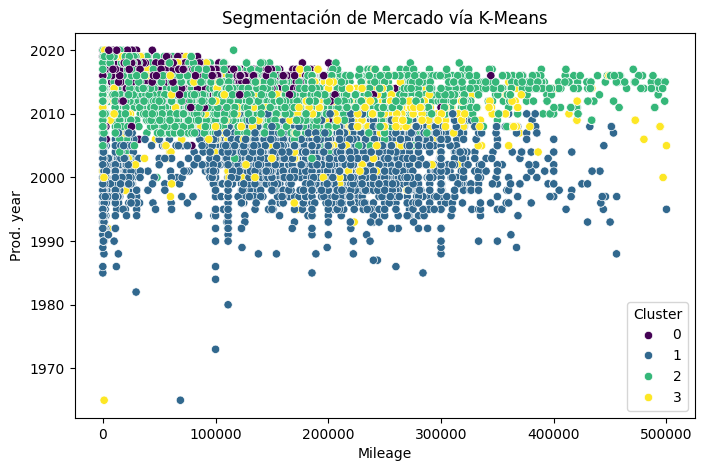

In [98]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Usar variables numéricas directamente del df, no el X del modelo
num_cols_km = ['Price', 'Mileage', 'Prod. year', 'Cylinders', 'Airbags', 'Levy']

scaler_km = StandardScaler()
X_scaled = scaler_km.fit_transform(df[num_cols_km].dropna())

# Ajustar K-Means con 4 grupos
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualización de los clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Mileage', y='Prod. year', hue='Cluster', palette='viridis')
plt.title('Segmentación de Mercado vía K-Means')
plt.show()


Vemos que hay 4 grupos más o menos diferenciados por el `Mileage` y el `Prod. year`. Se ven diferencias también en términos de precio?

In [99]:
df.groupby('Cluster')['Price'].mean()

Cluster
0    46447.476150
1    10460.943760
2    14026.078476
3    14769.554195
Name: Price, dtype: float64

> Tienen un precio medio diferente, sobre todo el 0 respecto a los otros

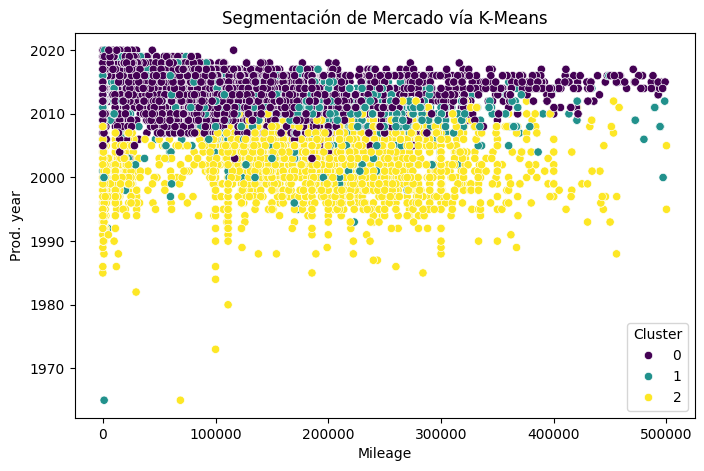

In [100]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Usar variables numéricas directamente del df, no el X del modelo
num_cols_km = ['Price', 'Mileage', 'Prod. year', 'Cylinders', 'Airbags', 'Levy']

scaler_km = StandardScaler()
X_scaled = scaler_km.fit_transform(df[num_cols_km].dropna())

# Ajustar K-Means con 4 grupos
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualización de los clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Mileage', y='Prod. year', hue='Cluster', palette='viridis')
plt.title('Segmentación de Mercado vía K-Means')
plt.show()


In [101]:
df.groupby('Cluster')['Price'].mean()

Cluster
0    19877.517783
1    19774.194152
2    10277.466304
Name: Price, dtype: float64

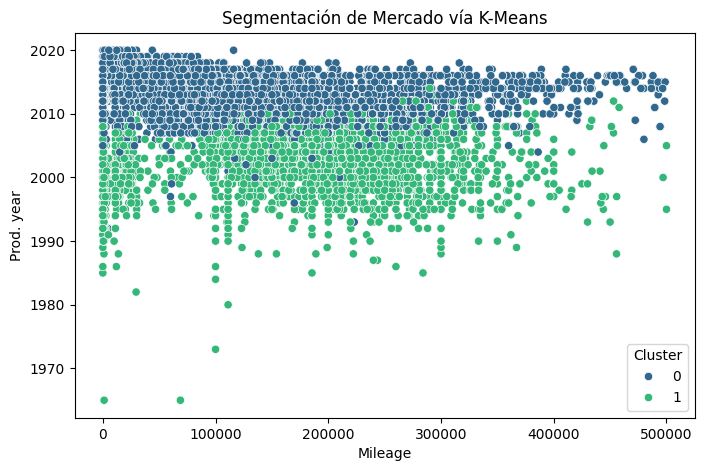

In [102]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Usar variables numéricas directamente del df, no el X del modelo
num_cols_km = ['Price', 'Mileage', 'Prod. year', 'Cylinders', 'Airbags', 'Levy']

scaler_km = StandardScaler()
X_scaled = scaler_km.fit_transform(df[num_cols_km].dropna())

# Ajustar K-Means con 4 grupos
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualización de los clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Mileage', y='Prod. year', hue='Cluster', palette='viridis')
plt.title('Segmentación de Mercado vía K-Means')
plt.show()


In [103]:
df.groupby('Cluster')['Price'].mean()

Cluster
0    19848.048825
1    11279.560326
Name: Price, dtype: float64

> A partir de los datos, se puede conclsuir que a partir de las variables de interés se puede discriminar 4 grupos para poder diferenciar los precios.

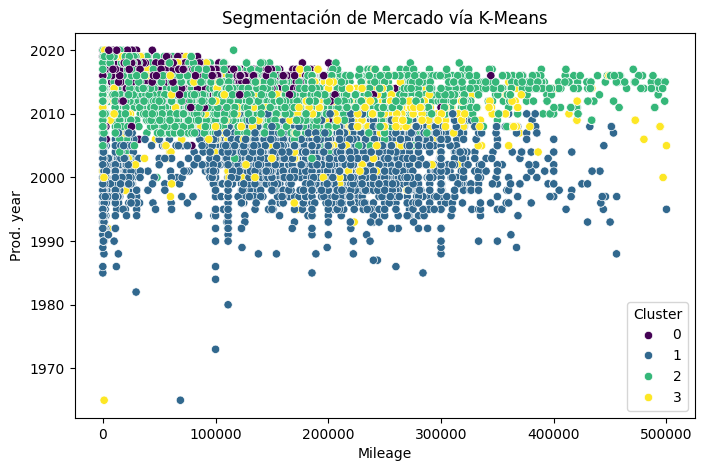

In [104]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Usar variables numéricas directamente del df, no el X del modelo
num_cols_km = ['Price', 'Mileage', 'Prod. year', 'Cylinders', 'Airbags', 'Levy']

scaler_km = StandardScaler()
X_scaled = scaler_km.fit_transform(df[num_cols_km].dropna())

# Ajustar K-Means con 4 grupos
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualización de los clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Mileage', y='Prod. year', hue='Cluster', palette='viridis')
plt.title('Segmentación de Mercado vía K-Means')
plt.show()

<Axes: xlabel='Cluster', ylabel='Price'>

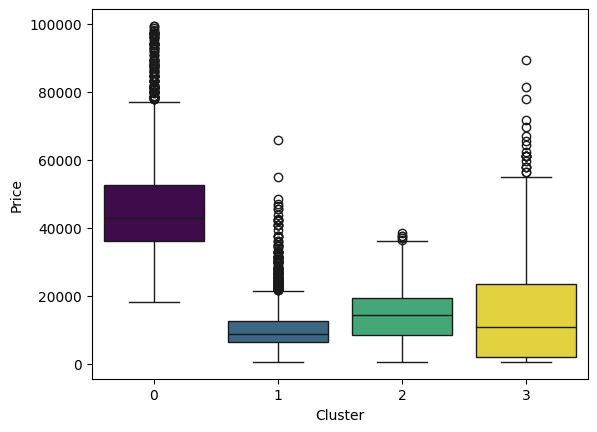

In [105]:
sns.boxplot(
        data=df, 
        x='Cluster', 
        y='Price', 
        palette='viridis',
        orient='v',
        hue='Cluster',       
        legend=False     
    )

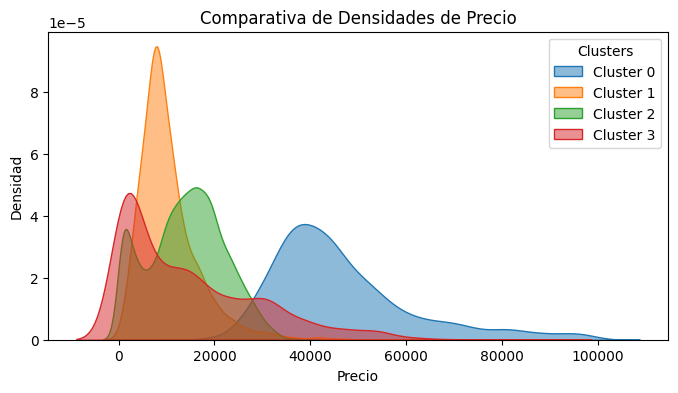

In [106]:
plt.figure(figsize=(8, 4))

for cluster in sorted(df['Cluster'].unique()):
    sns.kdeplot(
        data=df[df['Cluster'] == cluster],
        x='Price',
        fill=True,
        label=f'Cluster {cluster}',
        alpha=0.5
    )

plt.title('Comparativa de Densidades de Precio')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend(title='Clusters')
plt.show()

> Los del grupo 0 son los vehiculos de mayor precio, además se comprueba que los del grupo 3 alcanzan un mayor precio que los grupos 1 y 2. Respecto a estos dos últimos, el precio medio del grupo 1 es menor pero existen unidades de mayor precio que cualquiera de las existentes en el grupo 2. 

Redes Neuronales

In [107]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Definimos la arquitectura
model = models.Sequential([
    # Primera capa oculta: 32 neuronas, entrada dinámica según tus variables
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    
    # Capa de Dropout: Apaga neuronas al azar para evitar el overfitting
    layers.Dropout(0.2),
    
    # Segunda capa oculta: 16 neuronas
    layers.Dense(16, activation='relu'),
    
    # Capa de salida: 1 neurona para el precio (regresión)
    layers.Dense(1) 
])

# Compilación: Optimizador 'Adam' es el estándar moderno
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Entrenamiento
history = model.fit(
    X_train, y_train, 
    validation_split=0.2, 
    epochs=100, 
    batch_size=32, 
    verbose=0
)

c:\Users\LENOVO\Downloads\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


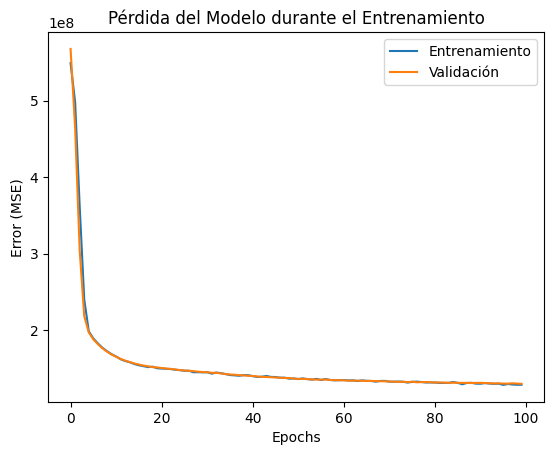

In [108]:
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo durante el Entrenamiento')
plt.xlabel('Epochs')
plt.ylabel('Error (MSE)')
plt.legend()
plt.show()

> Como se observa, el error de entrenamiento y validación convergen de forma similar a lo largo de las épocas, lo que indica que el modelo **no está sobreajustando** (overfitting).
>
> Es importante destacar que al inicio del entrenamiento el error de validación aparece por debajo del de entrenamiento. Esto es **normal y esperado** cuando se usa Dropout: durante el entrenamiento se apagan neuronas aleatoriamente (el modelo trabaja "mermado"), mientras que en validación todas las neuronas están activas, lo que produce un error inicial más bajo en validación. A medida que avanzan las épocas ambas curvas se estabilizan y convergen.
>
> En comparación con los modelos anteriores, la red neuronal obtiene resultados competitivos pero sin superar claramente a XGBoost o Random Forest en este dataset. Esto es habitual en problemas de datos tabulares estructurados, donde los modelos de gradient boosting suelen rendir igual o mejor que las redes neuronales con menor coste computacional.

In [109]:
# Obtener predicciones para el set de test
predictions = model.predict(X_test)

# Importante: Keras devuelve un array de arrays [[p1], [p2], ...]. 
# Lo aplanamos para que sea una lista sencilla de precios.
predictions = predictions.flatten()

# Ver las primeras 5
print(predictions[:5])

# Métricas de evaluación
from sklearn import metrics
print('MAE (Error Medio Absoluto):', metrics.mean_absolute_error(y_test, predictions))
print('MSE (Error Cuadrático Medio):', metrics.mean_squared_error(y_test, predictions))
print('RMSE (Raíz del Error Cuadrático Medio):', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('R2 Score (Varianza explicada):', metrics.r2_score(y_test, predictions))

159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[11739.361 17008.465 22996.79  11207.332 30971.883]
MAE (Error Medio Absoluto): 7692.2587890625
MSE (Error Cuadrático Medio): 129659072.0
RMSE (Raíz del Error Cuadrático Medio): 11386.793754169785
R2 Score (Varianza explicada): 0.43821901082992554


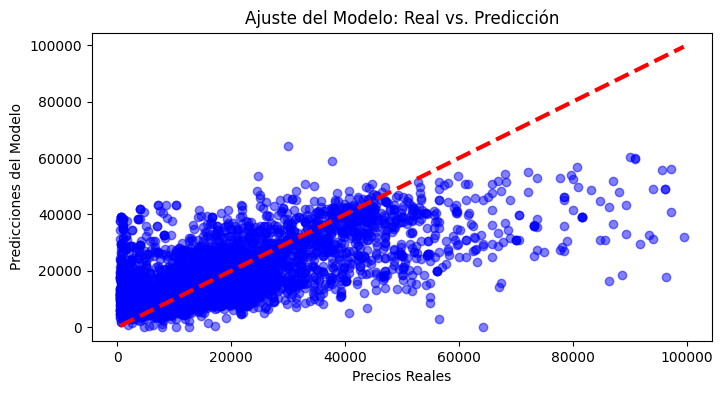

In [110]:
plt.figure(figsize=(8, 4))
plt.scatter(y_test, predictions, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3)
plt.xlabel('Precios Reales')
plt.ylabel('Predicciones del Modelo')
plt.title('Ajuste del Modelo: Real vs. Predicción')
plt.show()

> El scatter plot muestra la relación entre los precios reales y las predicciones de la red neuronal. Los puntos se distribuyen en torno a la diagonal roja (predicción perfecta), aunque con una dispersión considerable, especialmente en los rangos de precio más alto donde el modelo tiende a infraestimar.
>
> Las métricas finales de la red neuronal son:
> - **MAE**: 7.692 — el modelo se equivoca de media en ~7.700 unidades monetarias
> - **RMSE**: 11.387 — penaliza más los errores grandes, confirma dispersión en precios altos
> - **R²**: 0.438 — explica el 44% de la varianza del precio
>
> **Comparativa final de todos los modelos:**
>
> | Modelo | MAE | R² |
> |---|---|---|
> | Regresión Lineal | 8.581 | 0.356 |
> | Árbol de Decisión | 7.744 | 0.436 |
> | **Red Neuronal** | **7.692** | **0.438** |
> | XGBoost (optimizado) | 4.071 | 0.771 |
> | Random Forest | 4.082 | 0.769 |
>
> La red neuronal supera ligeramente a la regresión lineal y al árbol de decisión, pero queda muy por detrás de Random Forest y XGBoost. Esto confirma una conclusión habitual en Machine Learning: **para datos tabulares estructurados, los modelos de gradient boosting y ensemble suelen ser superiores a las redes neuronales**, que brillan más en datos no estructurados como imágenes, texto o audio. Con más datos, más capas o técnicas de regularización adicionales, la red neuronal podría mejorar, pero en este contexto XGBoost optimizado sigue siendo el modelo ganador.